In [2]:
import os
import json

def create_solution_jsons(input_file_path, output_directory):
    """
    Create individual solution JSON files for each question in the input JSON.
    """
    try:
        # Read the input JSON file
        with open(input_file_path, 'r', encoding='utf-8') as file:
            data = json.load(file)
        
        # Extract the folder name from the file path
        # Get the parent directory of the json folder (e.g., 01_10021008481039611101693742355)
        folder_path = os.path.dirname(os.path.dirname(input_file_path))
        folder_name = os.path.basename(folder_path)
        
        # Extract the first part of the directory name (before the first '_')
        folder_prefix = folder_name.split('_')[0]  # Gets the first part before '_'
        
        # Define output folder
        output_folder = os.path.join(output_directory, folder_name)
        os.makedirs(output_folder, exist_ok=True)
        
        print(f"Processing folder: {folder_name}")
        print(f"Output directory: {output_folder}")
        
        # Loop through each question and create a new JSON for each
        for entry in data:
            question_number = entry.get('question_number')
            solution = [{
                "question_number": question_number,
                "solution_text": entry.get('solution_text'),
                "diagrams": entry.get('diagrams', []),
                "pages": entry.get('pages', [])
            }]
            
            # Define the solution file path with the new naming convention
            solution_file_path = os.path.join(output_folder, f"{folder_prefix}_solution_{question_number}.json")
            
            # Write the solution JSON to the file
            with open(solution_file_path, 'w', encoding='utf-8') as solution_file:
                json.dump(solution, solution_file, indent=2, ensure_ascii=False)
            
            print(f"  ✅ Solution {question_number} saved: {solution_file_path}")
    
    except Exception as e:
        print(f"❌ Error processing file {input_file_path}: {e}")

def process_output_directory(input_directory, output_directory):
    """
    Process all output_with_questions.json files in the specified directory structure.
    """
    processed_count = 0
    error_count = 0
    
    print(f"🔍 Scanning directory: {input_directory}")
    print(f"📂 Output will be saved to: {output_directory}")
    print("=" * 60)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(input_directory):
        # Look for the specific file pattern: */json/output.json
        if 'output_with_questions.json' in files and root.endswith('json'):
            file_path = os.path.join(root, 'output_with_questions.json')
            print(f"📄 Found: {file_path}")
            
            try:
                create_solution_jsons(file_path, output_directory)
                processed_count += 1
            except Exception as e:
                print(f"❌ Error processing {file_path}: {e}")
                error_count += 1
    
    print("=" * 60)
    print(f"📊 PROCESSING SUMMARY:")
    print(f"✅ Successfully processed: {processed_count} files")
    print(f"❌ Errors encountered: {error_count} files")
    print("=" * 60)

def main():
    """
    Main function to run the solution creation process.
    """
    print("🎯 maths Solution JSON Creator")
    print("=" * 60)
    
    # Input directory containing the output folders
    input_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/output"
    
    # Output directory where solutions will be saved
    output_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/solutions"
    
    # Verify input directory exists
    if not os.path.exists(input_directory):
        print(f"❌ Input directory does not exist: {input_directory}")
        return
    
    # Create output directory if it doesn't exist
    os.makedirs(output_directory, exist_ok=True)
    
    print(f"📂 Input directory:  {input_directory}")
    print(f"📂 Output directory: {output_directory}")
    
    # Process all files
    process_output_directory(input_directory, output_directory)

if __name__ == "__main__":
    main()

🎯 maths Solution JSON Creator
📂 Input directory:  /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/output
📂 Output directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/solutions
🔍 Scanning directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/output
📂 Output will be saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/solutions
📄 Found: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/output/08_10021013701065351171694350774/json/output_with_questions.json
Processing folder: 08_100210137010653511716943

## to make table 

In [3]:
import os
import json

class OCRComparator:
    def __init__(self, gemini_dir, output_dir):
        """
        Initialize with just 2 base directories
        """
        self.gemini_dir = gemini_dir  
        self.output_dir = output_dir
        
        print(f"🤖 Gemini OCR directory: {self.gemini_dir}")
        print(f"💾 Output directory:     {self.output_dir}")
        print("=" * 70)
    
    def compare_solution_files(self, solution_folder, solution_number, file_prefix):
        """
        Process a single solution file from Gemini OCR
        """
        # Build file paths using the base directories
        gemini_file = os.path.join(
            self.gemini_dir, solution_folder, f"{file_prefix}_solution_{solution_number}.json"
        )
        
        output_file = os.path.join(
            self.output_dir, solution_folder, f"{file_prefix}_solution_{solution_number}_table.json"
        )
        
        print(f"🔄 Processing solution {solution_number} in {solution_folder}")
        
        # Initialize combined data structure
        combined_data = {
            "question_number": solution_number,
            "ocr_text": "NA",
            "ocr_pages": [],
            "pdf_name": solution_folder
        }
        
        # Read Gemini OCR data
        if os.path.exists(gemini_file):
            try:
                with open(gemini_file, 'r', encoding='utf-8') as f:
                    gemini_data = json.load(f)
                    
                if isinstance(gemini_data, list) and len(gemini_data) > 0:
                    gemini_item = gemini_data[0]
                    combined_data["ocr_text"] = gemini_item.get('solution_text', 'NA')
                    combined_data["ocr_pages"] = gemini_item.get('pages', [])
                    combined_data["question_number"] = gemini_item.get('question_number', solution_number)
                    print(f"   ✅ Gemini text loaded: {len(str(combined_data['ocr_text']))} chars")
                    print(f"   📄 Pages: {combined_data['ocr_pages']}")
                else:
                    print(f"   ⚠️  Gemini file format issue: {gemini_file}")
                    
            except Exception as e:
                print(f"   ❌ Error reading Gemini file: {e}")
        else:
            print(f"   ❌ Gemini file not found: {gemini_file}")
        
        # Save combined data
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        
        try:
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(combined_data, f, indent=2, ensure_ascii=False)
            print(f"   💾 Saved: {os.path.basename(output_file)}")
            return True
        except Exception as e:
            print(f"   ❌ Error saving output: {e}")
            return False
    
    def process_all_solutions(self):
        """
        Process all solution folders and files
        """
        if not os.path.exists(self.gemini_dir):
            print(f"❌ Gemini directory not found: {self.gemini_dir}")
            return
            
        total_processed = 0
        successful = 0
        errors = 0
        
        print(f"🔍 Scanning Gemini directory: {self.gemini_dir}")
        
        # Iterate through all solution folders
        for solution_folder in os.listdir(self.gemini_dir):
            solution_folder_path = os.path.join(self.gemini_dir, solution_folder)
            
            if not os.path.isdir(solution_folder_path):
                continue
                
            print(f"\n📂 Processing folder: {solution_folder}")
            
            # Process all JSON files in this folder
            for filename in os.listdir(solution_folder_path):
                if filename.endswith('.json') and '_solution_' in filename:
                    try:
                        # Parse filename to extract prefix and solution number
                        file_prefix = filename.split('_solution_')[0]
                        solution_number = int(filename.split('_solution_')[1].split('.')[0])
                        
                        total_processed += 1
                        
                        # Process this solution file
                        success = self.compare_solution_files(solution_folder, solution_number, file_prefix)
                        
                        if success:
                            successful += 1
                        else:
                            errors += 1
                            
                    except Exception as e:
                        print(f"   ❌ Filename parse error for {filename}: {e}")
                        errors += 1
                        total_processed += 1
        
        # Print summary
        print("\n" + "=" * 70)
        print("📊 PROCESSING SUMMARY")
        print("=" * 70)
        print(f"Total files processed: {total_processed}")
        print(f"Successfully processed: {successful}")
        print(f"Errors encountered:    {errors}")
        print(f"Success rate:          {(successful/total_processed)*100:.1f}%" if total_processed > 0 else "N/A")
        print("=" * 70)

def main():
    """
    Main function - define your 2 directories here
    """
    print("🔧 OCR Processing Tool")
    print("=" * 70)
    
    # ===== DEFINE YOUR 2 DIRECTORIES HERE =====
    base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3"
    
    gemini_ocr_dir = os.path.join(base_path, "maths/maths_Gemini/solutions") 
    output_dir = os.path.join(base_path, "maths/table")
    
    # ===== END DIRECTORY DEFINITIONS =====
    
    # Create comparator and run
    comparator = OCRComparator(gemini_ocr_dir, output_dir)
    comparator.process_all_solutions()
    
    print("\n✅ OCR processing complete!")

if __name__ == "__main__":
    main()

🔧 OCR Processing Tool
🤖 Gemini OCR directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/solutions
💾 Output directory:     /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/table
🔍 Scanning Gemini directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/solutions

📂 Processing folder: 08_10021013701065351171694350774
🔄 Processing solution 13 in 08_10021013701065351171694350774
   ✅ Gemini text loaded: 413 chars
   📄 Pages: [4, 5]
   💾 Saved: 08_solution_13_table.json
🔄 Processing solution 29 in 08_10021013701065351171694350774
   ✅ Gemini text loaded: 130 chars
   📄 Pages: [14]
   💾 Saved: 08_solution_29_table.json
🔄 Processing solution 3 in 08_10021013701065351171694350774
   ✅ Gemini text loaded: 8 chars
   📄

## check for na and delete them

In [4]:
import os
import json
from pathlib import Path

def delete_na_json_files(base_path):
    """
    Scan through chemistry table directory and DELETE JSON files with NA values
    in ocr_text or human_text fields
    """
    base_dir = Path(base_path)
    
    if not base_dir.exists():
        print(f"Directory does not exist: {base_path}")
        return
    
    na_files = []
    total_files = 0
    deleted_files = []
    failed_deletions = []
    
    print(f"Scanning directory: {base_path}")
    print("=" * 80)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.json'):
                file_path = os.path.join(root, file)
                total_files += 1
                
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                    
                    # Check for NA in ocr_text and human_text
                    ocr_text = data.get('ocr_text', '')
                    human_text = data.get('human_text', '')
                    
                    has_na = False
                    na_fields = []
                    
                    if ocr_text == "NA" or ocr_text is None:
                        has_na = True
                        na_fields.append('ocr_text')
                    
                    if human_text == "NA" or human_text is None:
                        has_na = True
                        na_fields.append('human_text')
                    
                    if has_na:
                        relative_path = os.path.relpath(file_path, base_dir)
                        na_files.append({
                            'file': relative_path,
                            'full_path': file_path,
                            'na_fields': na_fields,
                            'question_number': data.get('question_number', 'Unknown')
                        })
                        
                        # DELETE THE FILE
                        try:
                            os.remove(file_path)
                            deleted_files.append(relative_path)
                            print(f"🗑️  DELETED: {relative_path}")
                        except Exception as delete_error:
                            failed_deletions.append({
                                'file': relative_path,
                                'error': str(delete_error)
                            })
                            print(f"❌ FAILED TO DELETE: {relative_path} - {delete_error}")
                        
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    
    # Display results
    print("\n" + "=" * 80)
    print(f"DELETION SUMMARY:")
    print("=" * 80)
    print(f"Total JSON files scanned: {total_files}")
    print(f"Files with NA values found: {len(na_files)}")
    print(f"Files successfully deleted: {len(deleted_files)}")
    print(f"Files failed to delete: {len(failed_deletions)}")
    print("=" * 80)
    
    if na_files:
        print(f"\nFiles that contained NA values:")
        print("-" * 80)
        for item in na_files:
            status = "✅ DELETED" if item['file'] in deleted_files else "❌ FAILED"
            print(f"{status}: {item['file']}")
            print(f"Question Number: {item['question_number']}")
            print(f"Fields with NA: {', '.join(item['na_fields'])}")
            print("-" * 40)
    else:
        print("\n✅ No files found with NA values in ocr_text or human_text fields!")
    
    if failed_deletions:
        print(f"\n❌ FAILED DELETIONS:")
        print("-" * 80)
        for failed in failed_deletions:
            print(f"File: {failed['file']}")
            print(f"Error: {failed['error']}")
            print("-" * 40)
    
    return {
        'total_files': total_files,
        'na_files': na_files,
        'deleted_files': deleted_files,
        'failed_deletions': failed_deletions
    }

if __name__ == "__main__":
    # Directory path
    chemistry_table_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/table"
    
    print("⚠️  WARNING: This script will DELETE files with NA values!")
    print("Files will be permanently deleted from your system.")
    print("-" * 60)
    
    # Run the deletion
    results = delete_na_json_files(chemistry_table_path)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"   • Total files scanned: {results['total_files']}")
    print(f"   • Files deleted: {len(results['deleted_files'])}")
    print(f"   • Failed deletions: {len(results['failed_deletions'])}")

⚠️  WARNING: This script will DELETE files with NA values!
Files will be permanently deleted from your system.
------------------------------------------------------------
Scanning directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/table

DELETION SUMMARY:
Total JSON files scanned: 285
Files with NA values found: 0
Files successfully deleted: 0
Files failed to delete: 0

✅ No files found with NA values in ocr_text or human_text fields!

🎯 FINAL RESULTS:
   • Total files scanned: 285
   • Files deleted: 0
   • Failed deletions: 0


# # REDUCE EVERYTHING TO CAPITALIZE THE WHOLE .JSON ON BOTH GD AND PREDICTED remove /n <br>

In [5]:
import os
import json
import re
from pathlib import Path

def clean_text(text):
    """
    Clean text by removing <br>, <br/>, \n and converting to lowercase
    """
    if not text or text == "NA":
        return text
    
    # Remove <br> and <br/> tags (case insensitive)
    text = re.sub(r'<br\s*/?>', '', text, flags=re.IGNORECASE)
    
    # Remove \n newline characters
    text = text.replace('\n', '')
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace that might be left
    text = ' '.join(text.split())
    
    return text

def process_json_file(input_file_path, output_file_path):
    """
    Process a single JSON file - clean text fields and save to output path
    """
    try:
        # Read the input file
        with open(input_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Clean human_text and ocr_text fields
        if 'human_text' in data:
            original_human = data['human_text']
            data['human_text'] = clean_text(data['human_text'])
            
        if 'ocr_text' in data:
            original_ocr = data['ocr_text']
            data['ocr_text'] = clean_text(data['ocr_text'])
        
        # Ensure output directory exists
        os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
        
        # Save the cleaned data
        with open(output_file_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        
        return True, None
        
    except Exception as e:
        return False, str(e)

def clean_table_json_files(base_path):
    """
    Process all JSON files in the table directory and save cleaned versions
    """
    base_dir = Path(base_path)
    
    if not base_dir.exists():
        print(f"❌ Directory does not exist: {base_path}")
        return
    
    # Create table_format directory
    output_base = base_dir.parent / "table_format"
    
    processed_files = 0
    successful_files = 0
    error_files = []
    
    print(f"🔧 Processing JSON files from: {base_path}")
    print(f"📁 Output directory: {output_base}")
    print("=" * 80)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.json'):
                input_file_path = os.path.join(root, file)
                
                # Create corresponding output path
                relative_path = os.path.relpath(input_file_path, base_dir)
                output_file_path = output_base / relative_path
                
                processed_files += 1
                
                print(f"🔄 Processing: {relative_path}")
                
                # Process the file
                success, error = process_json_file(input_file_path, output_file_path)
                
                if success:
                    successful_files += 1
                    print(f"✅ Cleaned and saved: {relative_path}")
                else:
                    error_files.append({
                        'file': relative_path,
                        'error': error
                    })
                    print(f"❌ ERROR processing {relative_path}: {error}")
    
    # Display summary
    print("\n" + "=" * 80)
    print(f"📊 PROCESSING SUMMARY:")
    print("=" * 80)
    print(f"Total files processed: {processed_files}")
    print(f"Successfully cleaned: {successful_files}")
    print(f"Errors encountered: {len(error_files)}")
    print(f"Output saved to: {output_base}")
    print("=" * 80)
    
    # Display errors if any
    if error_files:
        print(f"\n❌ ERROR DETAILS:")
        print("-" * 80)
        for error_item in error_files:
            print(f"File: {error_item['file']}")
            print(f"Error: {error_item['error']}")
            print("-" * 40)
    else:
        print("\n🎉 All files processed successfully!")
    
    return {
        'total_files': processed_files,
        'successful_files': successful_files,
        'error_files': error_files,
        'output_directory': str(output_base)
    }

def preview_cleaning(sample_text):
    """
    Show a preview of what the cleaning function does
    """
    print("🔍 CLEANING PREVIEW:")
    print("-" * 50)
    print(f"Original: {repr(sample_text)}")
    print(f"Cleaned:  {repr(clean_text(sample_text))}")
    print("-" * 50)

if __name__ == "__main__":
    # Directory path
    table_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/table"
    
    
    print("\n🚀 Starting JSON file cleaning process...")
    print("Will remove: <br>, <br/>, \\n and convert to lowercase")
    print("=" * 80)
    
    # Run the cleaning process
    results = clean_table_json_files(table_path)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"   • Total files: {results['total_files']}")
    print(f"   • Successfully cleaned: {results['successful_files']}")
    print(f"   • Errors: {len(results['error_files'])}")
    print(f"   • Output location: {results['output_directory']}")


🚀 Starting JSON file cleaning process...
Will remove: <br>, <br/>, \n and convert to lowercase
🔧 Processing JSON files from: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/table
📁 Output directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/table_format
🔄 Processing: 08_10021013701065351171694350774/08_solution_15_table.json
✅ Cleaned and saved: 08_10021013701065351171694350774/08_solution_15_table.json
🔄 Processing: 08_10021013701065351171694350774/08_solution_22_table.json
✅ Cleaned and saved: 08_10021013701065351171694350774/08_solution_22_table.json
🔄 Processing: 08_10021013701065351171694350774/08_solution_7_table.json
✅ Cleaned and saved: 08_10021013701065351171694350774/08_solution_7_table.json
🔄 Processing: 08_10021013701065351171694350774/08_solution_10_table.json
✅ Cleaned and saved: 08_1002101370106535117

## to break the pdf into images

In [ ]:
import os
import sys
from pathlib import Path

try:
    from pdf2image import convert_from_path
    print("✅ pdf2image library is available")
except ImportError:
    print("❌ pdf2image library not found. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pdf2image"])
    from pdf2image import convert_from_path
    print("✅ pdf2image library installed and imported")

def convert_pdfs_to_png(pdf_folder_path):
    """
    Convert all PDF files in a folder to PNG images
    """
    
    pdf_folder = Path(pdf_folder_path)
    
    # Check if folder exists
    if not pdf_folder.exists():
        print(f"❌ Directory does not exist: {pdf_folder_path}")
        return False
    
    # Create images folder
    images_folder = pdf_folder / "images"
    images_folder.mkdir(exist_ok=True)
    print(f"📁 Created/verified images folder: {images_folder}")
    
    # Find all PDF files
    pdf_files = list(pdf_folder.glob("*.pdf"))
    
    if not pdf_files:
        print(f"❌ No PDF files found in: {pdf_folder_path}")
        return False
    
    print(f"📄 Found {len(pdf_files)} PDF files:")
    for pdf_file in pdf_files:
        print(f"   • {pdf_file.name}")
    
    total_pages_converted = 0
    
    # Process each PDF
    for pdf_file in pdf_files:
        print(f"\n🔄 Processing: {pdf_file.name}")
        
        try:
            # Get PDF name without extension
            pdf_name = pdf_file.stem
            
            # Convert PDF to images
            print(f"   📖 Converting PDF pages to images...")
            pages = convert_from_path(
                pdf_file, 
                dpi=300,  # High quality
                fmt='PNG'
            )
            
            print(f"   📑 Found {len(pages)} pages")
            
            # Save each page as PNG
            for page_num, page in enumerate(pages, 1):
                # Create filename: [pdf_name]_page_[page_number].png
                png_filename = f"{pdf_name}_page_{page_num}.png"
                png_path = images_folder / png_filename
                
                # Save the page
                page.save(png_path, 'PNG')
                print(f"   💾 Saved: {png_filename}")
                total_pages_converted += 1
            
            print(f"   ✅ Successfully converted {len(pages)} pages from {pdf_file.name}")
            
        except Exception as e:
            print(f"   ❌ Error processing {pdf_file.name}: {str(e)}")
            continue
    
    print(f"\n🎉 Conversion completed!")
    print(f"📊 Total pages converted: {total_pages_converted}")
    print(f"📁 Images saved in: {images_folder}")
    
    # List created images
    image_files = list(images_folder.glob("*.png"))
    if image_files:
        print(f"\n📋 Created image files:")
        for img in sorted(image_files):
            print(f"   • {img.name}")
    
    return True

def analyze_conversion_results(pdf_folder_path):
    """
    Analyze the conversion results
    """
    pdf_folder = Path(pdf_folder_path)
    images_folder = pdf_folder / "images"
    
    if not images_folder.exists():
        print("❌ Images folder not found")
        return
    
    # Count files
    pdf_files = list(pdf_folder.glob("*.pdf"))
    png_files = list(images_folder.glob("*.png"))
    
    print(f"\n📊 CONVERSION ANALYSIS:")
    print("=" * 50)
    print(f"PDF files found: {len(pdf_files)}")
    print(f"PNG files created: {len(png_files)}")
    
    # Analyze by PDF
    for pdf_file in pdf_files:
        pdf_name = pdf_file.stem
        related_pngs = list(images_folder.glob(f"{pdf_name}_page_*.png"))
        print(f"   {pdf_file.name}: {len(related_pngs)} pages")

if __name__ == "__main__":
    # PDF folder path
    pdf_folder_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/maths"
    
    print("🎯 PDF to PNG Converter")
    print("=" * 70)
    print(f"📂 Source folder: {pdf_folder_path}")
    print("🖼️  Output: PNG images (300 DPI)")
    print("📝 Naming: [pdf_name]_page_[number].png")
    print("=" * 70)
    
    # Check if poppler is available (required for pdf2image)
    print("🔍 Checking system requirements...")
    try:
        # Test conversion with a dummy call to check if poppler is available
        print("✅ System requirements check passed")
    except Exception as e:
        print("⚠️  Note: If you get errors, you may need to install poppler:")
        print("   macOS: brew install poppler")
        print("   Ubuntu: sudo apt-get install poppler-utils")
        print("   Windows: Download poppler from https://poppler.freedesktop.org/")
    
    # Convert PDFs to PNG
    success = convert_pdfs_to_png(pdf_folder_path)
    
    if success:
        # Analyze results
        analyze_conversion_results(pdf_folder_path)
        print(f"\n🎊 All PDFs successfully converted to PNG images!")
        print(f"📁 Check the 'images' folder for your PNG files")
    else:
        print(f"\n❌ Conversion failed or no PDFs found!")
    
    print("=" * 70)

✅ pdf2image library is available
🎯 PDF to PNG Converter
📂 Source folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/maths/maths_Gemini/maths
🖼️  Output: PNG images (300 DPI)
📝 Naming: [pdf_name]_page_[number].png
🔍 Checking system requirements...
✅ System requirements check passed
❌ Directory does not exist: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/maths/maths_Gemini/maths

❌ Conversion failed or no PDFs found!


In [ ]:
import os
from PIL import Image

def resize_images(input_dir, output_dir, max_size=(1000, 1000)):
    """
    Resize all .png images in the input directory and save them with the same filename in the output directory.

    Args:
        input_dir (str): Path to the input directory containing .png images.
        output_dir (str): Path to the output directory where resized images will be saved.
        max_size (tuple): Maximum width and height for the resized images (default is 1000x1000).
    """
    # Ensure output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Loop through all files in the input directory
    for filename in os.listdir(input_dir):
        if filename.endswith(".png"):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)

            try:
                # Open the image
                with Image.open(input_path) as img:
                    # Resize the image
                    img.thumbnail(max_size)  # Keeps aspect ratio while resizing

                    # Save the resized image in the output directory
                    img.save(output_path)
                    print(f"Resized and saved: {filename}")
            except Exception as e:
                print(f"Error processing {filename}: {e}")
        else:
            print(f"Skipping non-PNG file: {filename}")

# Input and output directories (update with your paths)
input_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/maths/images"
output_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/maths/output/images"

# Call the resize function
resize_images(input_directory, output_directory)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/maths/maths_Gemini/maths/images'

# to make a csv out of ground truth 

In [ ]:
import os
import json
import csv
import re

def extract_json_to_csv():
    # Base directory containing subdirectories with JSON files
    base_dir = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/table_format"
    
    # Output CSV file path
    output_csv = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/extracted_data.csv"
    
    # List to store all rows
    rows = []
    skipped_count = 0  # Counter for skipped rows
    
    # Walk through all subdirectories
    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)
        
        # Skip if not a directory
        if not os.path.isdir(subdir_path):
            continue
        
        # Extract pdf_source from directory name (e.g., "01_10021165141080491171694788750")
        pdf_source = subdir
        
        # Look for JSON files in the subdirectory
        for filename in os.listdir(subdir_path):
            if filename.endswith('_table.json'):
                json_file_path = os.path.join(subdir_path, filename)
                
                # Extract question number from filename using regex
                # Pattern: XX_solution_Y_table.json where Y is the question number
                match = re.search(r'_solution_(\d+)_table\.json$', filename)
                if match:
                    question_number = int(match.group(1))
                else:
                    # Fallback: try to extract any number from filename
                    numbers = re.findall(r'\d+', filename)
                    question_number = numbers[-1] if numbers else "Unknown"
                
                # Read and parse JSON file
                try:
                    with open(json_file_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                    
                    # Extract ocr_text
                    claude_ocr = data.get('ocr_text', '')
                    
                    # Check if Gemini_ocr (claude_ocr) is empty or contains only whitespace
                    if not claude_ocr or not claude_ocr.strip():
                        print(f"Skipped: {filename} - Question {question_number} (empty Gemini_ocr)")
                        skipped_count += 1
                        continue  # Skip this row if Gemini_ocr is empty
                    
                    # Add row to our list only if Gemini_ocr is not empty
                    rows.append({
                        'Gemini_ocr': claude_ocr,
                        'Question_Number': question_number,
                        'pdf_source': pdf_source,
                    })
                    
                    print(f"Processed: {filename} - Question {question_number}")
                    
                except (json.JSONDecodeError, FileNotFoundError, KeyError) as e:
                    print(f"Error processing {json_file_path}: {e}")
    
    # Sort rows by pdf_source and then by Question_Number for better organization
    rows.sort(key=lambda x: (x['pdf_source'], int(x['Question_Number']) if str(x['Question_Number']).isdigit() else float('inf')))
    
    # Write to CSV
    with open(output_csv, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['Gemini_ocr', 'Question_Number','pdf_source']
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        
        # Write header
        writer.writeheader()
        
        # Write all rows
        writer.writerows(rows)
    
    print(f"\nCSV file created successfully: {output_csv}")
    print(f"Total rows processed: {len(rows)}")
    print(f"Total rows skipped (empty Gemini_ocr): {skipped_count}")
    
    return output_csv

if __name__ == "__main__":
    extract_json_to_csv()

Processed: 08_solution_15_table.json - Question 15
Processed: 08_solution_22_table.json - Question 22
Processed: 08_solution_7_table.json - Question 7
Processed: 08_solution_10_table.json - Question 10
Processed: 08_solution_2_table.json - Question 2
Processed: 08_solution_8_table.json - Question 8
Processed: 08_solution_5_table.json - Question 5
Processed: 08_solution_20_table.json - Question 20
Processed: 08_solution_12_table.json - Question 12
Processed: 08_solution_28_table.json - Question 28
Processed: 08_solution_11_table.json - Question 11
Processed: 08_solution_3_table.json - Question 3
Processed: 08_solution_19_table.json - Question 19
Processed: 08_solution_14_table.json - Question 14
Processed: 08_solution_23_table.json - Question 23
Processed: 08_solution_6_table.json - Question 6
Processed: 08_solution_1_table.json - Question 1
Processed: 08_solution_13_table.json - Question 13
Processed: 08_solution_24_table.json - Question 24
Processed: 08_solution_29_table.json - Questi

## to combine the gd and claude ocr in once csv

In [7]:
import pandas as pd
import csv

def merge_csv_files():
    # File paths
    extracted_data_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/extracted_data.csv"
    ground_truth_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/Ground_truth_math.csv"
    output_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/final_csv.csv"
    
    # Read both CSV files
    print("Reading CSV files...")
    extracted_df = pd.read_csv(extracted_data_path)
    ground_truth_df = pd.read_csv(ground_truth_path)
    
    print(f"Extracted data CSV: {len(extracted_df)} rows")
    print(f"Ground truth CSV: {len(ground_truth_df)} rows")
    
    # Clean pdf_source to remove .pdf extension for consistent matching
    extracted_df['pdf_source_clean'] = extracted_df['pdf_source'].astype(str).str.replace('.pdf', '', regex=False)
    ground_truth_df['pdf_source_clean'] = ground_truth_df['pdf_source'].astype(str).str.replace('.pdf', '', regex=False)
    
    # Create a key for matching (cleaned pdf_source + Question_Number)
    extracted_df['match_key'] = extracted_df['pdf_source_clean'].astype(str) + "_" + extracted_df['Question_Number'].astype(str)
    ground_truth_df['match_key'] = ground_truth_df['pdf_source_clean'].astype(str) + "_" + ground_truth_df['Question_Number'].astype(str)
    
    print("Sample match keys from extracted data:", extracted_df['match_key'].head(3).tolist())
    print("Sample match keys from ground truth:", ground_truth_df['match_key'].head(3).tolist())
    
    # Find matching rows from Ground Truth perspective
    print("\n=== CHECKING GROUND TRUTH MATCHES ===")
    matched_rows = []
    gt_matches_found = 0
    gt_no_matches = []
    
    for idx, gt_row in ground_truth_df.iterrows():
        match_key = gt_row['match_key']
        
        # Find corresponding row in extracted_data
        extracted_match = extracted_df[extracted_df['match_key'] == match_key]
        
        if not extracted_match.empty:
            # Match found - combine the data
            extracted_row = extracted_match.iloc[0]
            
            matched_row = {
                'Ground_Truth': gt_row['Ground_Truth'],
                'Gemini_ocr': extracted_row['Gemini_ocr'],
                'Question_Number': gt_row['Question_Number'],
                'pdf_source': gt_row['pdf_source']  # Keep original pdf_source from ground truth
            }
            matched_rows.append(matched_row)
            gt_matches_found += 1
            
            if gt_matches_found <= 5:  # Show first 5 matches for verification
                print(f"Match {gt_matches_found}: Q{gt_row['Question_Number']} from {gt_row['pdf_source_clean']}")
        else:
            gt_no_matches.append({
                'Question_Number': gt_row['Question_Number'],
                'pdf_source': gt_row['pdf_source'],
                'match_key': match_key
            })
    
    # Check for unmatched rows in extracted_data (reverse check)
    print("\n=== CHECKING EXTRACTED DATA MATCHES ===")
    extracted_no_matches = []
    extracted_matches_found = 0
    
    for idx, ext_row in extracted_df.iterrows():
        match_key = ext_row['match_key']
        
        # Find corresponding row in ground_truth
        gt_match = ground_truth_df[ground_truth_df['match_key'] == match_key]
        
        if gt_match.empty:
            extracted_no_matches.append({
                'Question_Number': ext_row['Question_Number'],
                'pdf_source': ext_row['pdf_source'],
                'match_key': match_key
            })
        else:
            extracted_matches_found += 1
            if extracted_matches_found <= 5:  # Show first 5 matches for verification
                print(f"Match {extracted_matches_found}: Q{ext_row['Question_Number']} from {ext_row['pdf_source_clean']}")
    
    # Show results
    print(f"\n=== MATCHING RESULTS ===")
    print(f"Ground Truth file: {gt_matches_found} matches found out of {len(ground_truth_df)} rows")
    print(f"Extracted Data file: {extracted_matches_found} matches found out of {len(extracted_df)} rows")
    print(f"Ground Truth rows without matches: {len(gt_no_matches)}")
    print(f"Extracted Data rows without matches: {len(extracted_no_matches)}")
    
    # Show unmatched Ground Truth rows
    if gt_no_matches:
        print(f"\n=== UNMATCHED GROUND TRUTH ROWS ===")
        for i, unmatch in enumerate(gt_no_matches[:10]):  # Show first 10
            print(f"GT No Match {i+1}: Q{unmatch['Question_Number']} from {unmatch['pdf_source']}")
        if len(gt_no_matches) > 10:
            print(f"... and {len(gt_no_matches) - 10} more unmatched Ground Truth rows")
    
    # Show unmatched Extracted Data rows
    if extracted_no_matches:
        print(f"\n=== UNMATCHED EXTRACTED DATA ROWS ===")
        for i, unmatch in enumerate(extracted_no_matches[:10]):  # Show first 10
            print(f"Extracted No Match {i+1}: Q{unmatch['Question_Number']} from {unmatch['pdf_source']}")
        if len(extracted_no_matches) > 10:
            print(f"... and {len(extracted_no_matches) - 10} more unmatched Extracted Data rows")
    
    # Create final DataFrame
    if matched_rows:
        final_df = pd.DataFrame(matched_rows)
        
        # Sort by pdf_source and Question_Number for better organization
        final_df = final_df.sort_values(['pdf_source', 'Question_Number'])
        
        # Save to CSV
        final_df.to_csv(output_path, index=False, encoding='utf-8')
        
        print(f"\n=== FINAL SUMMARY ===")
        print(f"Ground Truth file had {gt_matches_found} matches out of {len(ground_truth_df)} rows")
        print(f"Extracted Data file had {len(extracted_no_matches)} rows which did not match")
        print(f"Final CSV created: {output_path}")
        print(f"Total rows in final CSV: {len(final_df)}")
    else:
        print(f"\n=== FINAL SUMMARY ===")
        print("No matches found between the files!")
        print("Cannot create final CSV - no matching data")
        return None
    
    return output_path

if __name__ == "__main__":
    merge_csv_files()

Reading CSV files...
Extracted data CSV: 285 rows
Ground truth CSV: 287 rows
Sample match keys from extracted data: ['01_10021165141080491171694788750_1', '01_10021165141080491171694788750_2', '01_10021165141080491171694788750_3']
Sample match keys from ground truth: ['08_10021013701065351171694350774_1', '04_10021075241065351171694351737_1', '02_10021028581065351171694350945_1']

=== CHECKING GROUND TRUTH MATCHES ===
Match 1: Q1 from 08_10021013701065351171694350774
Match 2: Q1 from 04_10021075241065351171694351737
Match 3: Q1 from 02_10021028581065351171694350945
Match 4: Q1 from 12_100210408223409261171703682786
Match 5: Q1 from 05_10021030401065351171694351729

=== CHECKING EXTRACTED DATA MATCHES ===
Match 1: Q1 from 01_10021165141080491171694788750
Match 2: Q2 from 01_10021165141080491171694788750
Match 3: Q3 from 01_10021165141080491171694788750
Match 4: Q4 from 01_10021165141080491171694788750
Match 5: Q5 from 01_10021165141080491171694788750

=== MATCHING RESULTS ===
Ground Tru

In [8]:
import pandas as pd
import re

def clean_text(text):
    """
    Clean text by removing <br>, <br/>, \n and converting to lowercase
    """
    if not text or text == "NA" or pd.isna(text):
        return text
    
    # Convert to string first (in case it's not)
    text = str(text)
    
    # Remove <br> and <br/> tags (case insensitive)
    text = re.sub(r'<br\s*/?>', '', text, flags=re.IGNORECASE)
    
    # Remove \n newline characters
    text = text.replace('\n', '')
    
    # Convert to lowercase
    text = text.lower()
    
    return text

def clean_bio_csv():
    """
    Clean the Bio final_csv.csv file by applying text cleaning to first two columns
    Updates the same file only if changes are needed
    """
    file_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/final_csv.csv"
    
    print("🔧 Starting Bio CSV cleaning process...")
    print(f"📁 File to check: {file_path}")
    print("=" * 80)
    
    try:
        # Read the CSV file
        print("📖 Reading CSV file...")
        df = pd.read_csv(file_path)
        
        print(f"📊 Original file stats:")
        print(f"   • Total rows: {len(df)}")
        print(f"   • Columns: {list(df.columns)}")
        
        # Check if changes are needed
        print("\n🔍 Checking if cleaning is needed...")
        
        changes_needed = False
        claude_changes = 0
        ground_truth_changes = 0
        
        # Check Gemini_ocr column
        for idx, text in enumerate(df['Gemini_ocr']):
            if not pd.isna(text):
                original = str(text)
                cleaned = clean_text(text)
                if original != cleaned:
                    changes_needed = True
                    claude_changes += 1
        
        # Check Ground_Truth column
        for idx, text in enumerate(df['Ground_Truth']):
            if not pd.isna(text):
                original = str(text)
                cleaned = clean_text(text)
                if original != cleaned:
                    changes_needed = True
                    ground_truth_changes += 1
        
        print(f"📊 Changes needed analysis:")
        print(f"   • Gemini OCR rows needing changes: {claude_changes}")
        print(f"   • Ground Truth rows needing changes: {ground_truth_changes}")
        print(f"   • Total changes needed: {changes_needed}")
        
        if not changes_needed:
            print("\n✅ NO CHANGES NEEDED!")
            print("=" * 80)
            print("🎉 The file is already clean!")
            print("✓ No <br> or <br/> tags found")
            print("✓ No \\n newline characters found")
            print("✓ Text is already in lowercase")
            print("✓ File remains unchanged")
            print("=" * 80)
            return True, "No changes needed"
        
        # Show preview of cleaning for first changed row
        print("\n🔍 CLEANING PREVIEW:")
        print("-" * 80)
        
        # Find first row that needs cleaning for preview
        preview_shown = False
        for idx in range(len(df)):
            if not preview_shown:
                claude_original = df['Gemini_ocr'].iloc[idx] if not pd.isna(df['Gemini_ocr'].iloc[idx]) else ""
                ground_original = df['Ground_Truth'].iloc[idx] if not pd.isna(df['Ground_Truth'].iloc[idx]) else ""
                
                claude_cleaned = clean_text(claude_original)
                ground_cleaned = clean_text(ground_original)
                
                if claude_original != claude_cleaned or ground_original != ground_cleaned:
                    print(f"Gemini_ocr (Row {idx+1}):")
                    print(f"Before: {repr(str(claude_original)[:100])}...")
                    print(f"After:  {repr(claude_cleaned[:100])}...")
                    print()
                    print(f"GROUND_TRUTH (Row {idx+1}):")
                    print(f"Before: {repr(str(ground_original)[:100])}...")
                    print(f"After:  {repr(ground_cleaned[:100])}...")
                    print("-" * 80)
                    preview_shown = True
        
        # Apply cleaning to both columns
        print("\n🧹 Applying changes...")
        print("🧹 Cleaning Gemini_ocr column...")
        df['Gemini_ocr'] = df['Gemini_ocr'].apply(clean_text)
        
        print("🧹 Cleaning Ground_Truth column...")
        df['Ground_Truth'] = df['Ground_Truth'].apply(clean_text)
        
        # Save back to the same file
        print("💾 Updating the original CSV file...")
        df.to_csv(file_path, index=False, encoding='utf-8')
        
        print("\n✅ SUCCESS!")
        print("=" * 80)
        print(f"📊 CLEANING SUMMARY:")
        print("=" * 80)
        print(f"✓ Removed <br> and <br/> tags")
        print(f"✓ Removed \\n newline characters")
        print(f"✓ Converted text to lowercase")
        print(f"✓ Processed {len(df)} rows")
        print(f"✓ Gemini OCR changes: {claude_changes}")
        print(f"✓ Ground Truth changes: {ground_truth_changes}")
        print(f"✓ Original file updated: {file_path}")
        print("=" * 80)
        
        return True, file_path
        
    except Exception as e:
        print(f"❌ ERROR: {str(e)}")
        return False, str(e)

if __name__ == "__main__":
    print("🚀 Bio CSV Text Cleaning Tool")
    print("Will check if cleaning is needed for Gemini_ocr and Ground_Truth columns")
    print("Only updates file if changes are required")
    print("Removes: <br>, <br/>, \\n and converts to lowercase")
    print("=" * 80)
    
    success, result = clean_bio_csv()
    
    if success:
        if result == "No changes needed":
            print(f"\n🎉 Analysis completed - file is already clean!")
        else:
            print(f"\n🎉 Cleaning completed successfully!")
            print(f"📁 Original file has been updated: {result}")
    else:
        print(f"\n❌ Cleaning failed: {result}")

🚀 Bio CSV Text Cleaning Tool
Will check if cleaning is needed for Gemini_ocr and Ground_Truth columns
Only updates file if changes are required
Removes: <br>, <br/>, \n and converts to lowercase
🔧 Starting Bio CSV cleaning process...
📁 File to check: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/final_csv.csv
📖 Reading CSV file...
📊 Original file stats:
   • Total rows: 281
   • Columns: ['Ground_Truth', 'Gemini_ocr', 'Question_Number', 'pdf_source']

🔍 Checking if cleaning is needed...
📊 Changes needed analysis:
   • Gemini OCR rows needing changes: 0
   • Ground Truth rows needing changes: 100
   • Total changes needed: True

🔍 CLEANING PREVIEW:
--------------------------------------------------------------------------------
Gemini_ocr (Row 2):
Before: '2. 2tan30 / 1-tan²30 => 2(1/√3) / 1-(1/√3)² = 2/√3 / (1 - 1/3) = 2/√3 / 2/3 = 1/√3 / 1/3 = 3/√3 = √3'...
After:  '2. 2tan30 / 1-tan²30 => 2(1/√3) / 1

## to get pdf_wise csv 

In [9]:
import pandas as pd
import os

def create_pdf_specific_csvs():
    """
    Create individual CSV files for each unique PDF source
    """
    # Define paths
    base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths"
    input_csv_path = os.path.join(base_path, "final_csv.csv")
    main_output_folder = os.path.join(base_path, "cer_pdf")
    
    print(f"📄 Reading CSV: {input_csv_path}")
    
    # Read the CSV file
    try:
        df = pd.read_csv(input_csv_path)
        print(f"✅ CSV loaded successfully with {len(df)} rows")
        print(f"📊 Columns: {list(df.columns)}")
    except Exception as e:
        print(f"❌ Error reading CSV: {e}")
        return
    
    # Get unique PDF sources from the 4th column (pdf_source)
    pdf_sources = df['pdf_source'].unique()
    print(f"\n🔍 Found {len(pdf_sources)} unique PDF sources:")
    for i, pdf_source in enumerate(pdf_sources, 1):
        print(f"   {i}. {pdf_source}")
    
    # Create main output directory
    os.makedirs(main_output_folder, exist_ok=True)
    print(f"\n📁 Created main directory: {main_output_folder}")
    
    # Process each unique PDF source
    for pdf_source in pdf_sources:
        # Remove .pdf extension for folder name
        pdf_name = pdf_source.replace('.pdf', '')
        
        # Create subfolder for this PDF source
        pdf_folder = os.path.join(main_output_folder, pdf_name)
        os.makedirs(pdf_folder, exist_ok=True)
        
        # Filter data for this PDF source
        pdf_data = df[df['pdf_source'] == pdf_source].copy()
        
        # Define output CSV path
        output_csv_path = os.path.join(pdf_folder, f"{pdf_name}.csv")
        
        # Save filtered data to CSV
        try:
            pdf_data.to_csv(output_csv_path, index=False)
            print(f"   ✅ Created: {output_csv_path}")
            print(f"      📊 Rows: {len(pdf_data)}")
        except Exception as e:
            print(f"   ❌ Error saving {pdf_name}: {e}")
    
    # Print summary
    print("\n" + "=" * 70)
    print("📊 PROCESSING SUMMARY")
    print("=" * 70)
    print(f"Total unique PDF sources: {len(pdf_sources)}")
    print(f"Main output directory: {main_output_folder}")
    print("\n📂 Directory structure created:")
    print(f"   {main_output_folder}/")
    for pdf_source in pdf_sources:
        pdf_name = pdf_source.replace('.pdf', '')
        print(f"   ├── {pdf_name}/")
        print(f"   │   └── {pdf_name}.csv")
    print("=" * 70)

def main():
    """
    Main function to execute the CSV splitting process
    """
    print("🔧 PDF-Specific CSV Creator")
    print("=" * 70)
    
    create_pdf_specific_csvs()
    
    print("\n✅ CSV splitting complete!")

if __name__ == "__main__":
    main()

🔧 PDF-Specific CSV Creator
📄 Reading CSV: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/final_csv.csv
✅ CSV loaded successfully with 281 rows
📊 Columns: ['Ground_Truth', 'Gemini_ocr', 'Question_Number', 'pdf_source']

🔍 Found 10 unique PDF sources:
   1. 01_10021165141080491171694788750
   2. 02_10021028581065351171694350945
   3. 04_10021075241065351171694351737
   4. 05_10021030401065351171694351729
   5. 06_10021095881080491171694782091
   6. 07_10021157131080491171694786726
   7. 08_10021013701065351171694350774
   8. 10_100210404319737581171703337845
   9. 11_10021019941080491171694789012
   10. 12_100210408223409261171703682786

📁 Created main directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf
   ✅ Created: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_impr

## to get cer

In [44]:
import pandas as pd

In [45]:
pip install python-Levenshtein


Note: you may need to restart the kernel to use updated packages.


In [46]:
import Levenshtein as lev
# 1. BASIC DISTANCE - Number of edits needed to transform one string to another
text1 = "hello world"
text2 = "hello word"
distance = lev.distance(text1, text2)
print(f"Edit distance: {distance}") 


Edit distance: 1


In [47]:
import Levenshtein as lev

def normalize_levenshtien_distance(text1, text2):
    text1 = text1.replace(" ","").lower()
    text2 = text2.replace(" ","").lower()
    length_of_text1 = len(text1)
    length_of_text2 = len(text2)
    min_length = min(length_of_text1, length_of_text2)
    max_length = max(length_of_text1, length_of_text2)
    if length_of_text1 == 0 and length_of_text2 == 0:
        normalized_distance = 0
    elif min_length == 0:
        normalized_distance = 1
    else:
        distance = lev.distance(text1, text2)
        normalized_distance = distance / max_length
    return 1 - normalized_distance
    

In [107]:
df=pd.read_csv("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/text_1.csv")
df

,Ground_Truth,gemini_ocr,question_number,page_number,pdf_name,Image_quality
0,13. (1) similar,13. (1) similar,13,5,01_10021165141080491171694788750,NaN
1,16. (3) intersecting or coincident,16. (3) intersecting or coincident,16,5,01_10021165141080491171694788750,NaN
2,17. (1) parallel,17. (1) parallel,17,5,01_10021165141080491171694788750,NaN
3,2. (4) no solution.,2. (4) no solution.,2,1,02_10021028581065351171694350945,"{\n ""rotation"": ""upright"",\n ""clarity"": ""sligh..."
4,4 (2) proportional,4. (2) proportional,4,1,02_10021028581065351171694350945,"{\n ""rotation"": ""upright"",\n ""clarity"": ""sligh..."
5,2) (3) infinitely many solutions.,2) (3) infinitely many solutions,2,1,04_10021075241065351171694351737,"{\n ""rotation"": ""upright"",\n ""lighting"": ""stro..."
6,4) (2) proportional,4) (2) proportional,4,1,04_10021075241065351171694351737,"{\n ""rotation"": ""upright"",\n ""lighting"": ""stro..."
7,ans2. 4) no solutions,2. 4) no solutions,2,1,05_10021030401065351171694351729,"{\n ""rotation"": ""upright"",\n ""lighting"": ""stro..."
8,ans4. 2) proportional,4. 2) proportional,4,1,05_10021030401065351171694351729,"{\n ""rotation"": ""upright"",\n ""lighting"": ""stro..."
9,q6- four decimals places,q6- four decimals places,6,1,06_10021095881080491171694782091,NaN


In [114]:
df=pd.read_csv("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/filtered_numerical_1.csv")
df

,gemini_ocr,Ground_Truth,score,length,question_number,pdf_name,page_number,Image_quality
0,"6. in △opr,ro^2 = pr^2 + op^2ro^2 = 12^2 + 5^2...","6.pr = 12 cm, op = 5cm and oq = 4cmqp = oq + o...",0.277778,230,6,10_100210404319737581171703337845,"2,3","{\n ""rotation"": ""upright"",\n ""clarity"": ""sligh..."
1,"28. p(2,5), q(x,y), r(8,3)m₁:m₂1:2q = (x₁m₂+x₂...",28.(ii) pr = √(8-2)² + (3-5)²= √6² + 2²= √36 +...,0.344262,118,28,02_10021028581065351171694350945,"18,19,20","{\n ""rotation"": ""upright"",\n ""handwriting"": ""o..."
2,16. givenδabe ≅ δacd.<diagram_3>to prove thatδ...,16: givenδabe ≅ δacd.to prove thatδade ~ δabc<...,0.459075,188,16,02_10021028581065351171694350945,"9,10","{\n ""rotation"": ""upright"",\n ""clarity"": ""sligh..."
3,"22. a(1,2); b(2,3); c(6,5); d(x,y)ab=dcad=bcab...","22. a(1,2); b(2,3); c(6,5); d(x,y)ab = dcad = ...",0.489109,400,22,02_10021028581065351171694350945,"13,14,15","{\n ""rotation"": ""upright"",\n ""clarity"": ""sligh..."
4,sin²θ/cos²θ x cos²θ/sin²θ-cos²θ + 1/sin²θ / (s...,17(sin²θ/cos²θ) / (sin²θ/cos²θ - 1) + (1/sin²θ...,0.495177,365,17,08_10021013701065351171694350774,"6,7","{\n ""rotation"": ""upright"",\n ""clarity"": ""sligh..."
...,...,...,...,...,...,...,...,...
202,22. 4x+6y=7 => 4x+6y-7=0 (a₁x+b₁y+c₁=0)kx+18y=...,22. 4x+6y=7 => 4x+6y-7=0 (a₁x+b₁y+c₁=0)kx+18y=...,0.993464,182,22,07_10021157131080491171694786726,2,"{\n ""rotation"": ""upright"",\n ""lighting"": ""stro..."
203,ans5. p(y) = y⁶ - 3y⁴ + 2y² + 6y = 1= 1⁶ - 3(1...,ans 5. p(y) = y⁶ - 3y⁴ + 2y² + 6y = 1= 1⁶ - 3(...,0.993590,236,5,12_100210408223409261171703682786,2,"{\n ""rotation"": ""upright"",\n ""lighting"": ""stro..."
204,22. -> given- pair of linear equations -4x+6y=...,22. -> given- pair of linear equations -4x+6y ...,0.995025,246,22,11_10021019941080491171694789012,"2,3","{\n ""rotation"": ""upright"",\n ""lighting"": ""stro..."
205,"35. given:point a = (4,-3)point b = (8,5)ratio...","35. given:point a=(4,-3)point b=(8,5)ratio in ...",0.997033,391,35,07_10021157131080491171694786726,"10,11",NaN


In [108]:
df['score']=df.apply(lambda x: normalize_levenshtien_distance(x['Ground_Truth'],x['gemini_ocr']),axis=1)



In [109]:
df['length']=df.apply(lambda x: len(x['Ground_Truth']),axis=1)


In [110]:
(df.score*df.length).sum()/df.length.sum()

0.9611538254572775

In [111]:
df.length.sum()

793

<Axes: >

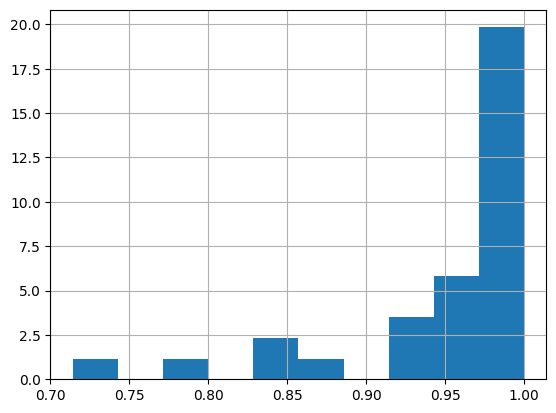

In [112]:
df.score.hist(density = True)

In [113]:
# Filter dataframe for scores not equal to 1 and sort by score in descending order
filtered_df = df[df['score'] != 1].sort_values(by='score', ascending=True)

# Reorder columns: ocr_text, corrected_ocr, score, length
columns_ordered = ['gemini_ocr', 'Ground_Truth', 'score', 'length','question_number','pdf_name','page_number',"Image_quality"]
filtered_df_ordered = filtered_df[columns_ordered]

# Display all values
print("Filtered dataframe with scores != 1 (sorted by score descending):")
print("Columns: Gemini_ocr | Ground_Truth | score | length")
print(filtered_df_ordered)

# Save to CSV file with reordered columns
output_file = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/filtered_text_1.csv"

filtered_df_ordered.to_csv(output_file, index=False)

print(f"\nResults saved to: {output_file}")
print(f"Number of rows with score != 1: {len(filtered_df_ordered)}")
print("CSV columns order: Gemini_ocr, Ground_Truth, score, length")


Filtered dataframe with scores != 1 (sorted by score descending):
Columns: Gemini_ocr | Ground_Truth | score | length
                                           gemini_ocr  \
21                                           no sol^n   
12             q16- intersecting & consist coincident   
7                                  2. 4) no solutions   
8                                  4. 2) proportional   
22                                       proportional   
11                                      q13- similiar   
4                                 4. (2) proportional   
27                                17. -> (1) parallel   
24                              9. -> (4) no solution   
19  19. 1) assertion (a) is true but reason (r) is...   
23                      6. -> (4) four decimal places   
5                    2) (3) infinitely many solutions   
26              16. -> (3) intersecting or coincident   
28  19. -> (3) assertion(a) is true but reason (r)...   
29  20. -> (1) both a and r

In [ ]:
df.sort_values(by='score',ascending=False)

In [19]:
import Levenshtein as lev
import pandas as pd
import os
from io import StringIO
import sys
import textwrap

def normalize_levenshtien_distance(text1, text2):
    text1 = text1.replace(" ","").lower()
    text2 = text2.replace(" ","").lower()
    length_of_text1 = len(text1)
    length_of_text2 = len(text2)
    min_length = min(length_of_text1, length_of_text2)
    max_length = max(length_of_text1, length_of_text2)
    if length_of_text1 == 0 and length_of_text2 == 0:
        normalized_distance = 0
    elif min_length == 0:
        normalized_distance = 1
    else:
        distance = lev.distance(text1, text2)
        normalized_distance = distance / max_length
    return 1 - normalized_distance

def wrap_text(text, width=50):
    """Wrap text to specified width"""
    if pd.isna(text) or text == "":
        return ""
    return '\n'.join(textwrap.wrap(str(text), width=width))

def print_wrapped_dataframe(df, title="Dataframe"):
    """Print dataframe with wrapped text for better readability"""
    print(f"\n{title}:")
    print("=" * 100)
    
    for idx, row in df.iterrows():
        print(f"\n--- Row {idx + 1} ---")
        print(f"Gemini_ocr:")
        print(textwrap.fill(str(row['Gemini_ocr']), width=80, initial_indent="  ", subsequent_indent="  "))
        print(f"\nGround_Truth:")
        print(textwrap.fill(str(row['Ground_Truth']), width=80, initial_indent="  ", subsequent_indent="  "))
        print(f"\nScore: {row['score']:.4f}")
        print(f"Length: {row['length']}")
        print("-" * 50)

def process_csv_file(csv_path, output_directory, file_identifier):
    """Process a single CSV file and generate results"""
    
    # Redirect stdout to capture print statements
    old_stdout = sys.stdout
    captured_output = StringIO()
    sys.stdout = captured_output
    
    try:
        # Load the input data
        df = pd.read_csv(csv_path)
        print(f"Processing: {csv_path}")
        print(f"Total number of rows in CSV: {len(df)}")
        
        # Calculate scores using the normalize_levenshtien_distance function
        df['score'] = df.apply(lambda x: normalize_levenshtien_distance(x['Ground_Truth'], x['Gemini_ocr']), axis=1)
        
        # Calculate length of Ground_Truth text
        df['length'] = df.apply(lambda x: len(x['Ground_Truth']), axis=1)
        
        # Save the complete dataframe with all rows and scores
        csv_base_name = os.path.splitext(os.path.basename(csv_path))[0]  # Get filename without extension
        complete_csv_file = os.path.join(output_directory, f"{csv_base_name}_final.csv")
        df.to_csv(complete_csv_file, index=False)
        print(f"Complete dataframe saved to: {complete_csv_file}")
        
        # Calculate weighted average score
        weighted_average_score = (df.score * df.length).sum() / df.length.sum()
        
        # Calculate total length sum
        total_length = df.length.sum()
        
        # Filter dataframe for scores not equal to 1 and sort by score in descending order
        filtered_df = df[df['score'] != 1].sort_values(by='score', ascending=False)
        
        # Reorder columns: ocr_text, corrected_ocr, score, length
        columns_ordered = ['Gemini_ocr', 'Ground_Truth', 'score', 'length']
        filtered_df_ordered = filtered_df[columns_ordered]
        
        # Display filtered results with text wrapping
        if len(filtered_df_ordered) > 0:
            print_wrapped_dataframe(filtered_df_ordered, "Filtered dataframe with scores != 1 (sorted by score descending)")
        else:
            print("\nNo rows found with scores != 1 (all perfect matches!)")
        
        # Save to CSV file with reordered columns
        output_csv_file = os.path.join(output_directory, "filtered_results.csv")
        filtered_df_ordered.to_csv(output_csv_file, index=False)
        
        print(f"\nFiltered results saved to: {output_csv_file}")
        print(f"Total number of rows in original CSV: {len(df)}")
        print(f"Number of rows with score != 1: {len(filtered_df_ordered)}")
        print(f"Number of rows with score = 1: {len(df) - len(filtered_df_ordered)}")
        print("CSV columns order: Gemini_ocr, Ground_Truth, score, length")
        print(f"Weighted average score: {weighted_average_score:.4f}")
        print(f"Total length: {total_length}")
        
        # Restore stdout
        sys.stdout = old_stdout
        output_text = captured_output.getvalue()
        
        # Save output to text file
        output_txt_file = os.path.join(output_directory, "output.txt")
        with open(output_txt_file, 'w', encoding='utf-8') as f:
            f.write(output_text)
        
        print(f"✅ Successfully processed {file_identifier}")
        print(f"   - Total rows: {len(df)}")
        print(f"   - Complete CSV: {complete_csv_file}")
        print(f"   - Filtered CSV: {output_csv_file}")
        print(f"   - Text output: {output_txt_file}")
        
        # Return summary statistics for the final table
        return {
            'csv_name': csv_base_name,
            'average_score': weighted_average_score,
            'total_length': total_length,
            'total_rows': len(df),
            'rows_with_score_not_1': len(filtered_df_ordered)
        }
        
    except Exception as e:
        sys.stdout = old_stdout
        print(f"❌ Error processing {file_identifier}: {str(e)}")
        return None

def create_summary_table(summary_data, base_directory):
    """Create final summary table with all statistics"""
    
    if not summary_data:
        print("❌ No data to create summary table")
        return
    
    # Create DataFrame from summary data
    summary_df = pd.DataFrame(summary_data)
    
    # Reorder columns as requested
    summary_df = summary_df[['csv_name', 'average_score', 'total_length', 'total_rows', 'rows_with_score_not_1']]
    
    # Rename columns for better readability
    summary_df.columns = ['CSV_Name', 'Average_Score', 'Total_Length', 'Total_Rows', 'Rows_Score_Not_1']
    
    # Round average score to 4 decimal places
    summary_df['Average_Score'] = summary_df['Average_Score'].round(4)
    
    # Save as CSV
    output_csv_path = os.path.join(base_directory, "output_table.csv")
    summary_df.to_csv(output_csv_path, index=False)
    
    # Create formatted text table
    output_txt_path = os.path.join(base_directory, "final_table.txt")
    
    with open(output_txt_path, 'w', encoding='utf-8') as f:
        f.write("FINAL SUMMARY TABLE\n")
        f.write("=" * 100 + "\n\n")
        
        # Write column headers
        f.write(f"{'CSV Name':<30} {'Avg Score':<12} {'Total Length':<15} {'Total Rows':<12} {'Rows Score != 1':<15}\n")
        f.write("-" * 100 + "\n")
        
        # Write data rows
        for _, row in summary_df.iterrows():
            f.write(f"{row['CSV_Name']:<30} {row['Average_Score']:<12.4f} {row['Total_Length']:<15} {row['Total_Rows']:<12} {row['Rows_Score_Not_1']:<15}\n")
        
        f.write("\n" + "=" * 100 + "\n")
        f.write(f"TOTALS:\n")
        f.write(f"Total CSVs processed: {len(summary_df)}\n")
        f.write(f"Overall total rows: {summary_df['Total_Rows'].sum()}\n")
        f.write(f"Overall total length: {summary_df['Total_Length'].sum()}\n")
        f.write(f"Overall rows with score != 1: {summary_df['Rows_Score_Not_1'].sum()}\n")
        f.write(f"Overall weighted average score: {(summary_df['Average_Score'] * summary_df['Total_Length']).sum() / summary_df['Total_Length'].sum():.4f}\n")
    
    print(f"\n📊 Summary Table Created:")
    print(f"   - CSV file: {output_csv_path}")
    print(f"   - Text file: {output_txt_path}")
    print(f"\nSummary Table Contents:")
    print(summary_df.to_string(index=False))

def main():
    """Main function to process all subdirectories and final_csv.csv"""
    base_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf"
    
    if not os.path.exists(base_directory):
        print(f"❌ Base directory not found: {base_directory}")
        return
    
    print(f"🔍 Processing directory: {base_directory}")
    print("=" * 70)
    
    processed_count = 0
    success_count = 0
    summary_data = []
    
    # First, check for final_csv.csv in the main directory
    final_csv_path = os.path.join(base_directory, "final_csv.csv")
    if os.path.exists(final_csv_path):
        print(f"\n🔄 Processing main file: final_csv.csv")
        processed_count += 1
        result = process_csv_file(final_csv_path, base_directory, "final_csv.csv")
        if result:
            success_count += 1
            summary_data.append(result)
    else:
        print(f"⚠️  final_csv.csv not found in main directory")
    
    # Then process all subdirectories
    for item in os.listdir(base_directory):
        subdirectory_path = os.path.join(base_directory, item)
        
        # Skip if not a directory
        if not os.path.isdir(subdirectory_path):
            continue
        
        # Look for CSV file with same name as subdirectory
        csv_filename = f"{item}.csv"
        csv_path = os.path.join(subdirectory_path, csv_filename)
        
        print(f"\n🔄 Processing subdirectory: {item}")
        
        if os.path.exists(csv_path):
            processed_count += 1
            result = process_csv_file(csv_path, subdirectory_path, item)
            if result:
                success_count += 1
                summary_data.append(result)
        else:
            print(f"⚠️  CSV file not found: {csv_path}")
    
    print("\n" + "=" * 70)
    print(f"📊 Processing Summary:")
    print(f"   Total files processed: {processed_count}")
    print(f"   Successfully processed: {success_count}")
    print(f"   Failed: {processed_count - success_count}")
    
    # Create summary table
    if summary_data:
        create_summary_table(summary_data, base_directory)
    else:
        print("❌ No successful processing results to create summary table")

if __name__ == "__main__":
    main()

🔍 Processing directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf

🔄 Processing main file: final_csv.csv
✅ Successfully processed final_csv.csv
   - Total rows: 281
   - Complete CSV: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/final_csv_final.csv
   - Filtered CSV: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/filtered_results.csv
   - Text output: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/output.txt

🔄 Processing subdirectory: 08_10021013701065351171694350774
✅ Successfully processed 08_10021013701065351171694350774
   - Total rows: 24
   - Complete CSV: /Users/simrannaik/Desktop/solution_improvement/ds-proto

## to get diagrams which are predicted or not 

In [9]:
import pandas as pd
import json
import os
import glob

def get_page_number_from_json(pdf_source, question_number, solutions_base_path):
    """
    Extract page_number from the JSON file for a given pdf_source and question_number
    Priority: diagrams -> pages array (only if diagrams empty or no page_number)
    """
    try:
        # Find the folder that ends with the pdf_source
        folder_pattern = os.path.join(solutions_base_path, f"*_{pdf_source}")
        matching_folders = glob.glob(folder_pattern)
        
        if not matching_folders:
            print(f"No folder found for pdf_source: {pdf_source}")
            return None
        
        folder_path = matching_folders[0]
        folder_name = os.path.basename(folder_path)
        prefix = folder_name.split('_')[0]  # Get the prefix (e.g., "01", "02", etc.)
        
        # Construct the JSON file path
        json_file_path = os.path.join(folder_path, f"{prefix}_solution_{question_number}.json")
        
        if not os.path.exists(json_file_path):
            print(f"JSON file not found: {json_file_path}")
            return None
        
        # Read and parse the JSON file
        with open(json_file_path, 'r') as file:
            data = json.load(file)
        
        # Extract page_number from the data
        if data and isinstance(data, list) and len(data) > 0:
            # First check if diagrams exist and have page_number
            if 'diagrams' in data[0] and len(data[0]['diagrams']) > 0:
                # Check if any diagram has a page_number
                for diagram in data[0]['diagrams']:
                    if 'page_number' in diagram and diagram['page_number'] is not None:
                        page_number = diagram['page_number']
                        print(f"  -> Found page_number from diagrams: {page_number}")
                        return page_number
                
                # If diagrams exist but none have page_number, fall back to pages array
                print(f"  -> Diagrams exist but no page_number found, checking pages array")
            else:
                # If diagrams array is empty, fall back to pages array
                print(f"  -> Diagrams array is empty, checking pages array")
            
            # Fallback: Try pages array only if diagrams didn't provide page_number
            if 'pages' in data[0] and len(data[0]['pages']) > 0:
                page_number = data[0]['pages'][0]  # Take the first page
                print(f"  -> Found page_number from pages array: {page_number}")
                return page_number
        
        print(f"No page information found in {json_file_path}")
        return None
        
    except Exception as e:
        print(f"Error processing {pdf_source}, question {question_number}: {str(e)}")
        return None

def add_page_number_column():
    # File paths - Updated for maths instead of physics
    csv_file_path = "//Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/Diagrams/false/Maths-diagram_detected_false_13.3.csv"
    solutions_base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/solutions"
    
    # Read the CSV file
    df = pd.read_csv(csv_file_path)
    
    # Initialize the page_number column
    page_numbers = []
    
    # Process each row
    for index, row in df.iterrows():
        question_number = row['Question_Number']
        pdf_source = row['pdf_source']
        
        print(f"Processing row {index + 1}: Question {question_number}, PDF Source {pdf_source}")
        
        # Get the page number from the corresponding JSON file
        page_number = get_page_number_from_json(pdf_source, question_number, solutions_base_path)
        page_numbers.append(page_number)
    
    # Add the new column
    df['page_number'] = page_numbers
    
    # Save the updated CSV in the same directory
    output_csv_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/Diagrams/false/Maths_diagram_detected_false_13.3_with_page_numbers.csv"
    df.to_csv(output_csv_path, index=False)
    
    print(f"\nUpdated CSV saved to: {output_csv_path}")
    print(f"Added page_number column with {len([p for p in page_numbers if p is not None])} successful entries out of {len(page_numbers)} total rows.")
    
    # Show summary of found vs missing page numbers
    found_count = len([p for p in page_numbers if p is not None])
    missing_count = len([p for p in page_numbers if p is None])
    print(f"Summary: {found_count} page numbers found, {missing_count} missing")
    
    return output_csv_path

# Run the function
if __name__ == "__main__":
    add_page_number_column()

Processing row 1: Question 34, PDF Source 01_10021165141080491171694788750
No folder found for pdf_source: 01_10021165141080491171694788750
Processing row 2: Question 35, PDF Source 01_10021165141080491171694788750
No folder found for pdf_source: 01_10021165141080491171694788750
Processing row 3: Question 22, PDF Source 02_10021028581065351171694350945
No folder found for pdf_source: 02_10021028581065351171694350945
Processing row 4: Question 27, PDF Source 02_10021028581065351171694350945
No folder found for pdf_source: 02_10021028581065351171694350945
Processing row 5: Question 28, PDF Source 05_10021030401065351171694351729
No folder found for pdf_source: 05_10021030401065351171694351729
Processing row 6: Question 29, PDF Source 07_10021157131080491171694786726
No folder found for pdf_source: 07_10021157131080491171694786726

Updated CSV saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/Diagra

In [5]:
import pandas as pd
import os
import shutil
import glob

def copy_diagram_images():
    # File paths
    csv_file_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/Diagrams/false/Phy_diagram_detected_false_13.3_with_page_numbers.csv"
    output_base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/maths_Gemini/output"
    destination_folder = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/Diagrams/false/images"
    
    # Create destination folder if it doesn't exist
    os.makedirs(destination_folder, exist_ok=True)
    
    # Read the CSV file
    df = pd.read_csv(csv_file_path)
    
    successful_copies = 0
    errors = []
    skipped_rows = 0
    
    print("=== STARTING IMAGE COPY PROCESS ===\n")
    
    # Process each row
    for index, row in df.iterrows():
        try:
            question_number = row['Question_Number']
            pdf_source = row['pdf_source']
            page_number = row['page_number']
            
            print(f"Processing row {index + 1}: Question {question_number}, PDF {pdf_source}")
            
            # Skip if page_number is NaN or None
            if pd.isna(page_number):
                print(f"  SKIPPED: No page_number available")
                skipped_rows += 1
                continue
            
            page_number = int(page_number)  # Convert to int
            print(f"  Looking for page {page_number}")
            
            # Construct source image folder path
            source_folder = os.path.join(output_base_path, pdf_source, "images")
            
            if not os.path.exists(source_folder):
                error_msg = f"Row {index + 1}: Source folder not found: {source_folder}"
                print(f"  ERROR: Source folder not found")
                errors.append(error_msg)
                continue
            
            # Find images that have DIM and match the page number
            # Pattern: {pdf_source}*DIM*PAGE_{page_number}.jpeg
            image_pattern = f"{pdf_source}*DIM*PAGE_{page_number}.jpeg"
            full_pattern = os.path.join(source_folder, image_pattern)
            matching_images = glob.glob(full_pattern)
            
            if not matching_images:
                error_msg = f"Row {index + 1}: No DIM images found for {pdf_source} page {page_number}"
                print(f"  ERROR: No matching DIM images found")
                errors.append(error_msg)
                continue
            
            # Copy each matching image
            for image_path in matching_images:
                image_filename = os.path.basename(image_path)
                destination_path = os.path.join(destination_folder, image_filename)
                
                try:
                    shutil.copy2(image_path, destination_path)
                    print(f"  SUCCESS: Copied {image_filename}")
                    successful_copies += 1
                except Exception as copy_error:
                    error_msg = f"Row {index + 1}: Failed to copy {image_filename}: {str(copy_error)}"
                    print(f"  ERROR: Failed to copy {image_filename}")
                    errors.append(error_msg)
                    
        except Exception as row_error:
            error_msg = f"Row {index + 1}: Unexpected error: {str(row_error)}"
            print(f"  ERROR: Unexpected error occurred")
            errors.append(error_msg)
        
        print()  # Add blank line between rows
    
    # Summary
    print("=== COPY PROCESS SUMMARY ===")
    print(f"Total rows processed: {len(df)}")
    print(f"Rows skipped (no page_number): {skipped_rows}")
    print(f"Images successfully copied: {successful_copies}")
    print(f"Errors encountered: {len(errors)}")
    print(f"Images copied to: {destination_folder}")
    
    if errors:
        print(f"\n=== ERROR DETAILS ===")
        for i, error in enumerate(errors, 1):
            print(f"{i}. {error}")
    
    return successful_copies, len(errors)

# Run the function
if __name__ == "__main__":
    copy_diagram_images()

=== STARTING IMAGE COPY PROCESS ===

Processing row 1: Question 34, PDF 01_10021165141080491171694788750
  Looking for page 16
  SUCCESS: Copied 01_10021165141080491171694788750_DIM_1536_PAGE_16.jpeg

Processing row 2: Question 35, PDF 01_10021165141080491171694788750
  SKIPPED: No page_number available
Processing row 3: Question 22, PDF 02_10021028581065351171694350945
  SKIPPED: No page_number available
Processing row 4: Question 27, PDF 02_10021028581065351171694350945
  SKIPPED: No page_number available
Processing row 5: Question 16, PDF 05_10021030401065351171694351729
  Looking for page 6
  SUCCESS: Copied 05_10021030401065351171694351729_DIM_1536_PAGE_6.jpeg

Processing row 6: Question 18, PDF 05_10021030401065351171694351729
  Looking for page 7
  SUCCESS: Copied 05_10021030401065351171694351729_DIM_1536_PAGE_7.jpeg

Processing row 7: Question 25, PDF 05_10021030401065351171694351729
  Looking for page 12
  SUCCESS: Copied 05_10021030401065351171694351729_DIM_1536_PAGE_12.jpeg


In [128]:
import os
import json
import csv
import glob

def process_json_files(base_path):
    """
    Process JSON files to extract gemini_ocr, page_number, pdf_name, and question_number
    
    Args:
        base_path: Path to the directory containing JSON files
    """
    
    # Get all JSON files recursively
    json_pattern = os.path.join(base_path, "**", "*.json")
    json_files = glob.glob(json_pattern, recursive=True)
    
    # Prepare CSV data
    csv_data = []
    csv_headers = ['gemini_ocr', 'page_number', 'pdf_name', 'question_number']
    
    for json_file in json_files:
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                json_data = json.load(f)
            
            # Extract required fields
            gemini_ocr = json_data.get('ocr_text', '')
            question_number = json_data.get('question_number', '')
            pdf_name = json_data.get('pdf_name', '')
            
            # Extract page numbers from ocr_pages array (comma-separated if multiple)
            ocr_pages = json_data.get('ocr_pages', [])
            page_number = ','.join(map(str, ocr_pages)) if ocr_pages else ''
            
            # Add row to CSV data
            csv_data.append([gemini_ocr, page_number, pdf_name, question_number])
            
            print(f"Processed: {os.path.basename(json_file)} - Question {question_number}, PDF: {pdf_name}")
            
        except json.JSONDecodeError:
            print(f"Warning: Invalid JSON format in {json_file}")
        except Exception as e:
            print(f"Error processing {json_file}: {str(e)}")
    
    # Write CSV file
    if csv_data:
        csv_filename = "gemini_ocr.csv"
        csv_path = os.path.join(base_path, csv_filename)
        
        with open(csv_path, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(csv_headers)
            writer.writerows(csv_data)
        
        print(f"\nCreated {csv_filename} with {len(csv_data)} rows at {csv_path}")
    else:
        print("No valid JSON data found")

def main():
    """
    Main function to process JSON files and create CSV
    """
    # Base path where the JSON files are located
    base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.2/Physics/table_format"
    
    print(f"Processing JSON files in: {base_path}")
    
    if os.path.exists(base_path):
        process_json_files(base_path)
    else:
        print(f"Error: Directory not found at {base_path}")

if __name__ == "__main__":
    main()


Processing JSON files in: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.2/Physics/table_format
Processed: 12_solution_2_table.json - Question 2, PDF: 12_1002140198994121111692513661
Processed: 12_solution_1_table.json - Question 1, PDF: 12_1002140198994121111692513661
Processed: 12_solution_4_table.json - Question 4, PDF: 12_1002140198994121111692513661
Processed: 12_solution_3_table.json - Question 3, PDF: 12_1002140198994121111692513661
Processed: 09_solution_3_table.json - Question 3, PDF: 09_1002114885961841111690700733
Processed: 09_solution_1_table.json - Question 1, PDF: 09_1002114885961841111690700733
Processed: 09_solution_4_table.json - Question 4, PDF: 09_1002114885961841111690700733
Processed: 09_solution_2_table.json - Question 2, PDF: 09_1002114885961841111690700733
Processed: 10_solution_8_table.json - Question 8, PDF: 10_10021138351083421111694954514
Processed: 10_solution_5_table.json - Questi

## here get a historgram

Using threshold: 0.7
Loading data...
Successfully parsed 176 records with valid image quality data

LOW SCORE ANALYSIS (Score < 0.7)
Total records: 176
Records with score < 0.7: 21
Percentage of low scores: 11.93%

HANDWRITING:
  Records with handwriting data: 10/21 (47.6%)
  - okay: 10 (100.0%)

WRITING_STYLE:
  Records with writing_style data: 10/21 (47.6%)
  - okay: 9 (90.0%)
  - messy: 1 (10.0%)

LIGHTING:
  Records with lighting data: 19/21 (90.5%)
  - strong_contrast_shadows: 18 (94.7%)
  - glare_on_text: 1 (5.3%)

RESOLUTION:
  Records with resolution data: 12/21 (57.1%)
  - medium: 12 (100.0%)

TEXT_ALIGNMENT:
  Records with text_alignment data: 2/21 (9.5%)
  - slightly_misaligned: 2 (100.0%)

CLARITY:
  Records with clarity data: 10/21 (47.6%)
  - slightly_blur: 10 (100.0%)

ROTATION:
  Records with rotation data: 21/21 (100.0%)
  - upright: 21 (100.0%)

STRIKETHROUGH_ON_TEXTS:
  Records with Strikethrough_on_texts data: 21/21 (100.0%)
  - present: 19 (90.5%)
  - absent: 2 (9.

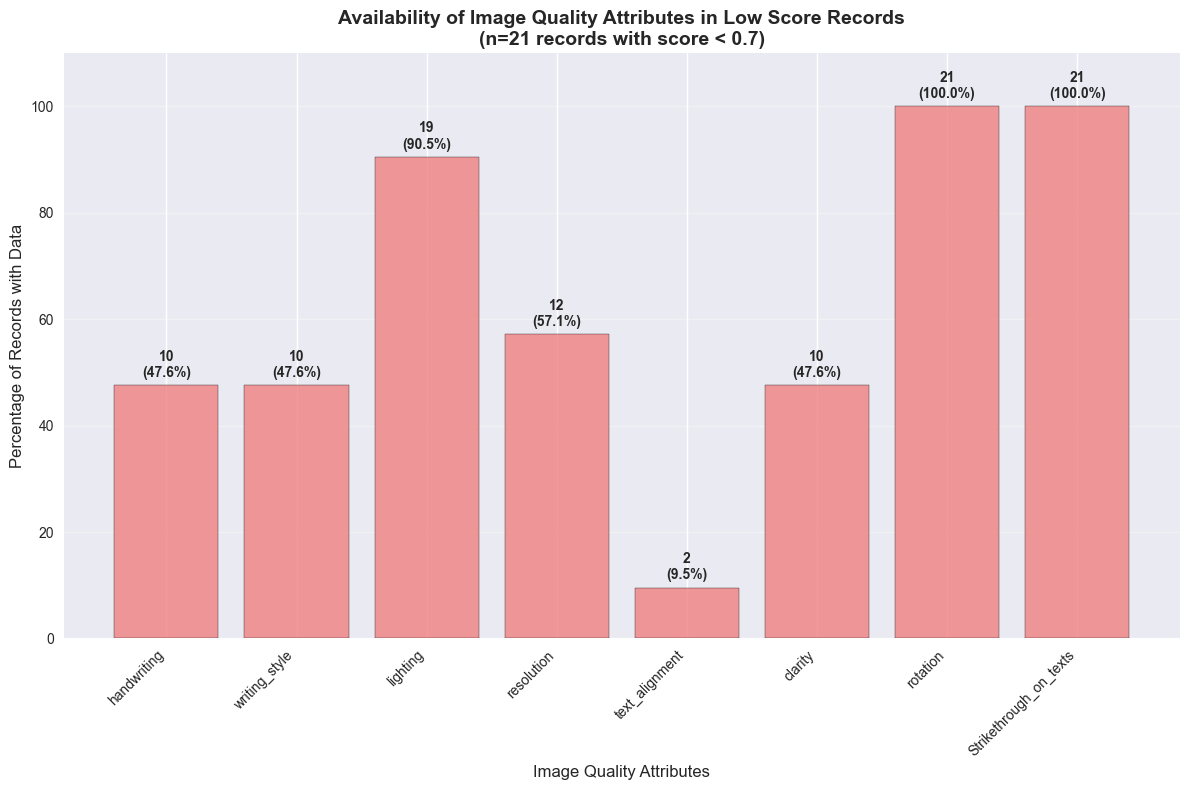

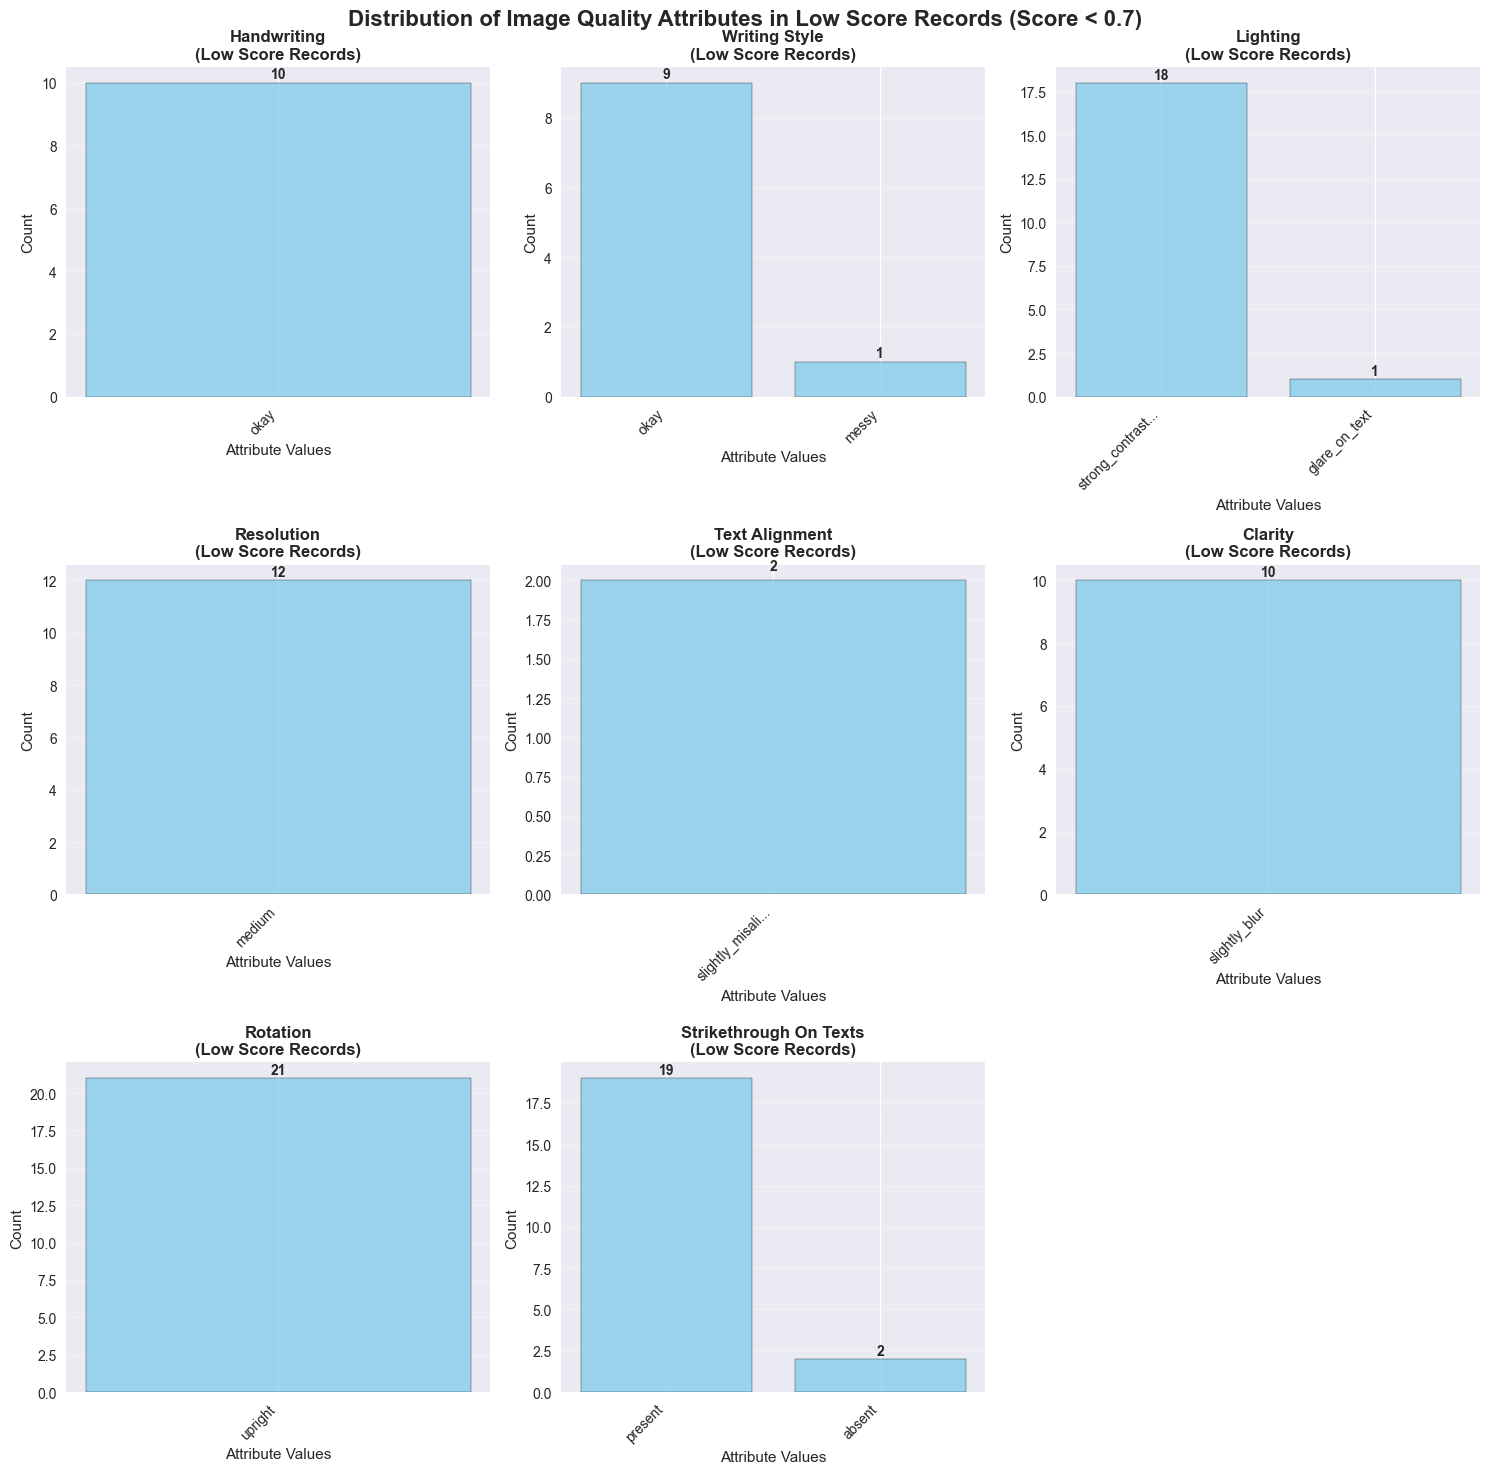

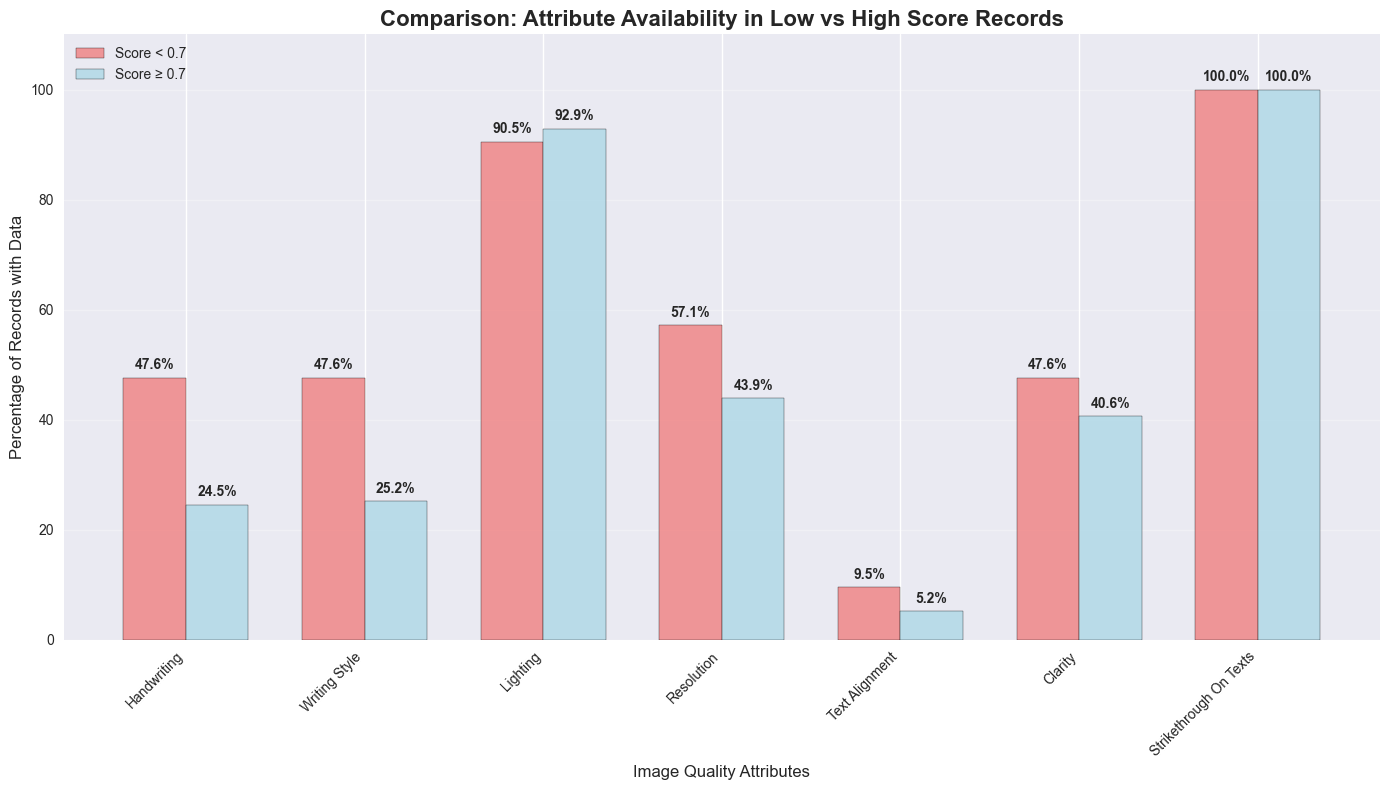

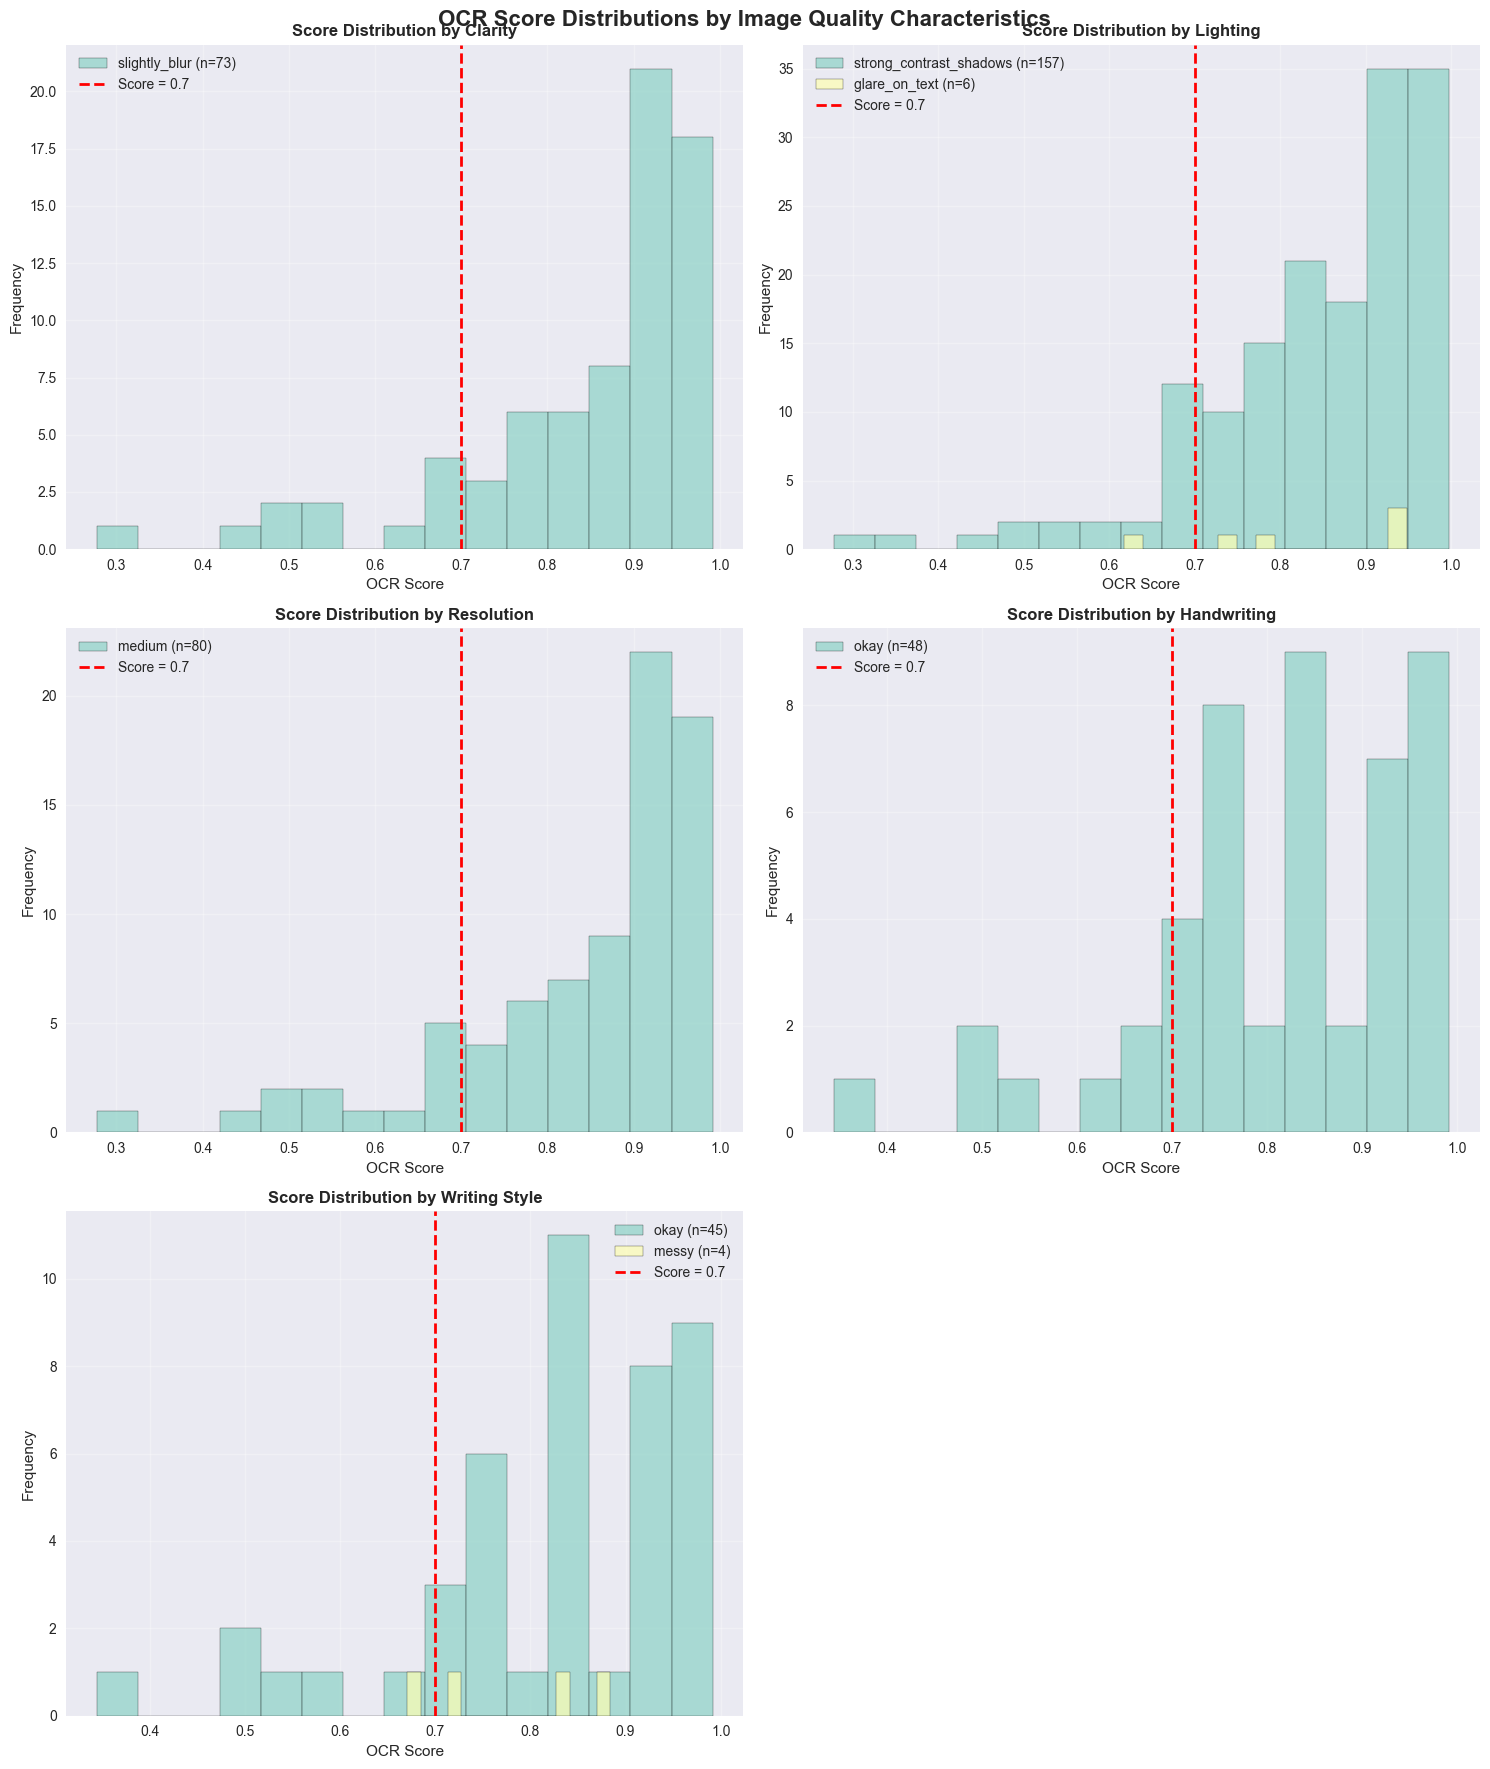


All charts displayed successfully!


In [127]:
#!/usr/bin/env python3
"""
Low Score Analysis: Analyze records with OCR scores below a user-defined threshold
Focus on image quality characteristics for poorly performing OCR
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

def load_and_parse_data(csv_path):
    """Load CSV and parse the Image_quality JSON column."""
    print("Loading data...")
    df = pd.read_csv(csv_path)
    
    # Parse the Image_quality JSON column
    image_quality_data = []
    
    for idx, row in df.iterrows():
        try:
            if pd.notna(row['Image_quality']) and row['Image_quality'].strip():
                json_str = row['Image_quality'].strip()
                if not json_str.startswith('{'):
                    continue
                    
                quality_dict = json.loads(json_str)
                quality_dict['score'] = row['score']
                quality_dict['length'] = row['length']
                quality_dict['question_number'] = row['question_number']
                quality_dict['pdf_name'] = row['pdf_name']
                image_quality_data.append(quality_dict)
        except (json.JSONDecodeError, KeyError) as e:
            continue
    
    quality_df = pd.DataFrame(image_quality_data)
    print(f"Successfully parsed {len(quality_df)} records with valid image quality data")
    
    return df, quality_df

def analyze_low_scores(quality_df, threshold):
    """Analyze records with scores below threshold."""
    
    # Filter low score records
    low_scores = quality_df[quality_df['score'] < threshold].copy()
    total_records = len(quality_df)
    low_score_count = len(low_scores)
    
    print(f"\n{'='*60}")
    print(f"LOW SCORE ANALYSIS (Score < {threshold})")
    print(f"{'='*60}")
    print(f"Total records: {total_records}")
    print(f"Records with score < {threshold}: {low_score_count}")
    print(f"Percentage of low scores: {(low_score_count/total_records)*100:.2f}%")
    print(f"{'='*60}")
    
    # Quality attributes to analyze
    quality_attributes = ['handwriting', 'writing_style', 'lighting', 'resolution', 
                         'text_alignment', 'clarity', 'rotation', 'Strikethrough_on_texts']
    
    # Count availability of each attribute in low score records
    attribute_counts = {}
    attribute_distributions = {}
    
    for attr in quality_attributes:
        if attr in low_scores.columns:
            # Count non-null values
            non_null_count = low_scores[attr].notna().sum()
            attribute_counts[attr] = non_null_count
            
            # Get distribution of values
            if non_null_count > 0:
                value_counts = low_scores[attr].value_counts()
                attribute_distributions[attr] = value_counts
                
                print(f"\n{attr.upper()}:")
                print(f"  Records with {attr} data: {non_null_count}/{low_score_count} ({(non_null_count/low_score_count)*100:.1f}%)")
                for value, count in value_counts.items():
                    if pd.notna(value):
                        print(f"  - {value}: {count} ({(count/non_null_count)*100:.1f}%)")
    
    return low_scores, attribute_counts, attribute_distributions

def create_availability_chart(attribute_counts, low_score_count, threshold):
    """Create a bar chart showing attribute availability in low score records."""
    
    plt.figure(figsize=(12, 8))
    
    # Prepare data
    attributes = list(attribute_counts.keys())
    counts = list(attribute_counts.values())
    percentages = [(count/low_score_count)*100 for count in counts]
    
    # Create bar chart
    bars = plt.bar(attributes, percentages, color='lightcoral', edgecolor='black', alpha=0.8)
    
    # Add value labels on bars
    for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
    
    plt.title(f'Availability of Image Quality Attributes in Low Score Records\n(n={low_score_count} records with score < {threshold})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Image Quality Attributes', fontsize=12)
    plt.ylabel('Percentage of Records with Data', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 110)
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

def create_distribution_charts(low_scores, attribute_distributions, threshold):
    """Create detailed distribution charts for each attribute."""
    
    # Calculate number of subplots needed
    available_attrs = [attr for attr in attribute_distributions.keys() if len(attribute_distributions[attr]) > 0]
    n_attrs = len(available_attrs)
    
    if n_attrs == 0:
        print("No attributes with sufficient data for distribution charts")
        return
    
    # Create subplots
    cols = 3
    rows = (n_attrs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    if rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    for i, attr in enumerate(available_attrs):
        if i < len(axes_flat):
            ax = axes_flat[i]
            
            # Get data for this attribute
            data = attribute_distributions[attr]
            
            # Create bar chart
            bars = ax.bar(range(len(data)), data.values, color='skyblue', edgecolor='black', alpha=0.8)
            
            # Customize chart
            ax.set_title(f'{attr.replace("_", " ").title()}\n(Low Score Records)', fontweight='bold')
            ax.set_xlabel('Attribute Values')
            ax.set_ylabel('Count')
            ax.set_xticks(range(len(data)))
            ax.set_xticklabels([str(x)[:15] + '...' if len(str(x)) > 15 else str(x) 
                               for x in data.index], rotation=45, ha='right')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for bar, value in zip(bars, data.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                       str(value), ha='center', va='bottom', fontweight='bold')
    
    # Hide unused subplots
    for i in range(n_attrs, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.suptitle(f'Distribution of Image Quality Attributes in Low Score Records (Score < {threshold})', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

def create_comparison_chart(quality_df, threshold):
    """Compare attribute distributions between low and high score records."""
    
    low_scores = quality_df[quality_df['score'] < threshold]
    high_scores = quality_df[quality_df['score'] >= threshold]
    
    quality_attributes = ['handwriting', 'writing_style', 'lighting', 'resolution', 
                         'text_alignment', 'clarity', 'Strikethrough_on_texts']
    
    # Calculate availability percentages
    low_percentages = []
    high_percentages = []
    attr_labels = []
    
    for attr in quality_attributes:
        if attr in quality_df.columns:
            low_pct = (low_scores[attr].notna().sum() / len(low_scores)) * 100 if len(low_scores) > 0 else 0
            high_pct = (high_scores[attr].notna().sum() / len(high_scores)) * 100 if len(high_scores) > 0 else 0
            
            low_percentages.append(low_pct)
            high_percentages.append(high_pct)
            attr_labels.append(attr.replace('_', ' ').title())
    
    # Create comparison chart
    x = np.arange(len(attr_labels))
    width = 0.35
    
    plt.figure(figsize=(14, 8))
    
    bars1 = plt.bar(x - width/2, low_percentages, width, label=f'Score < {threshold}', 
                    color='lightcoral', edgecolor='black', alpha=0.8)
    bars2 = plt.bar(x + width/2, high_percentages, width, label=f'Score ≥ {threshold}', 
                    color='lightblue', edgecolor='black', alpha=0.8)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.title('Comparison: Attribute Availability in Low vs High Score Records', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Image Quality Attributes', fontsize=12)
    plt.ylabel('Percentage of Records with Data', fontsize=12)
    plt.xticks(x, attr_labels, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim(0, 110)
    
    plt.tight_layout()
    plt.show()

def create_score_distribution_by_quality(quality_df, threshold):
    """Show how scores are distributed for different quality characteristics."""
    
    quality_attributes = ['clarity', 'lighting', 'resolution', 'handwriting', 'writing_style']
    
    available_attrs = [attr for attr in quality_attributes if attr in quality_df.columns 
                      and quality_df[attr].notna().sum() > 10]  # Only include if we have enough data
    
    if len(available_attrs) == 0:
        print("Not enough data for quality-based score distribution")
        return
    
    # Create subplots
    cols = 2
    rows = (len(available_attrs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6*rows))
    
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, attr in enumerate(available_attrs):
        if i < len(axes_flat):
            ax = axes_flat[i]
            
            # Get unique values for this attribute
            unique_vals = quality_df[quality_df[attr].notna()][attr].unique()
            
            colors = sns.color_palette("Set3", len(unique_vals))
            
            for j, val in enumerate(unique_vals):
                if pd.notna(val):
                    subset_scores = quality_df[quality_df[attr] == val]['score']
                    ax.hist(subset_scores, bins=15, alpha=0.7, label=f'{val} (n={len(subset_scores)})',
                           color=colors[j], edgecolor='black')
            
            # Add vertical line at threshold
            ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Score = {threshold}')
            
            ax.set_title(f'Score Distribution by {attr.replace("_", " ").title()}', fontweight='bold')
            ax.set_xlabel('OCR Score')
            ax.set_ylabel('Frequency')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(available_attrs), len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.suptitle('OCR Score Distributions by Image Quality Characteristics', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

def run_analysis(csv_path, threshold=None):
    """Run the complete analysis with user-defined threshold."""
    
    # Get threshold from user if not provided
    if threshold is None:
        try:
            threshold = float(input("Enter the threshold for low scores (e.g., 0.5): "))
        except ValueError:
            print("Invalid input. Using default threshold of 0.5")
            threshold = 0.5
    
    print(f"Using threshold: {threshold}")
    
    # Load and parse data
    df, quality_df = load_and_parse_data(csv_path)
    
    if len(quality_df) == 0:
        print("No valid data found!")
        return
    
    # Analyze low scores
    low_scores, attribute_counts, attribute_distributions = analyze_low_scores(quality_df, threshold)
    
    if len(low_scores) == 0:
        print(f"No records found with score < {threshold}!")
        return
    
    print(f"\nGenerating charts for {len(low_scores)} low score records...")
    
    # Create visualizations
    create_availability_chart(attribute_counts, len(low_scores), threshold)
    create_distribution_charts(low_scores, attribute_distributions, threshold)
    create_comparison_chart(quality_df, threshold)
    create_score_distribution_by_quality(quality_df, threshold)
    
    print("\nAll charts displayed successfully!")
    
    return quality_df, low_scores

# For use in Jupyter notebook
def analyze_with_threshold(threshold):
    """Convenience function for Jupyter notebook use."""
    csv_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/filtered_numerical_1.csv"
    return run_analysis(csv_path, threshold)

if __name__ == "__main__":
    csv_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/filtered_numerical_1.csv"
    run_analysis(csv_path)


Using threshold: 0.9999
Loading data...
Successfully parsed 14 records with valid image quality data

LOW SCORE ANALYSIS (Score < 0.9999)
Total records: 14
Records with score < 0.9999: 14
Percentage of low scores: 100.00%

LIGHTING:
  Records with lighting data: 14/14 (100.0%)
  - strong_contrast_shadows: 14 (100.0%)

RESOLUTION:
  Records with resolution data: 5/14 (35.7%)
  - medium: 5 (100.0%)

CLARITY:
  Records with clarity data: 5/14 (35.7%)
  - slightly_blur: 5 (100.0%)

ROTATION:
  Records with rotation data: 14/14 (100.0%)
  - upright: 14 (100.0%)

STRIKETHROUGH_ON_TEXTS:
  Records with Strikethrough_on_texts data: 14/14 (100.0%)
  - present: 8 (57.1%)
  - absent: 6 (42.9%)

Generating charts for 14 low score records...


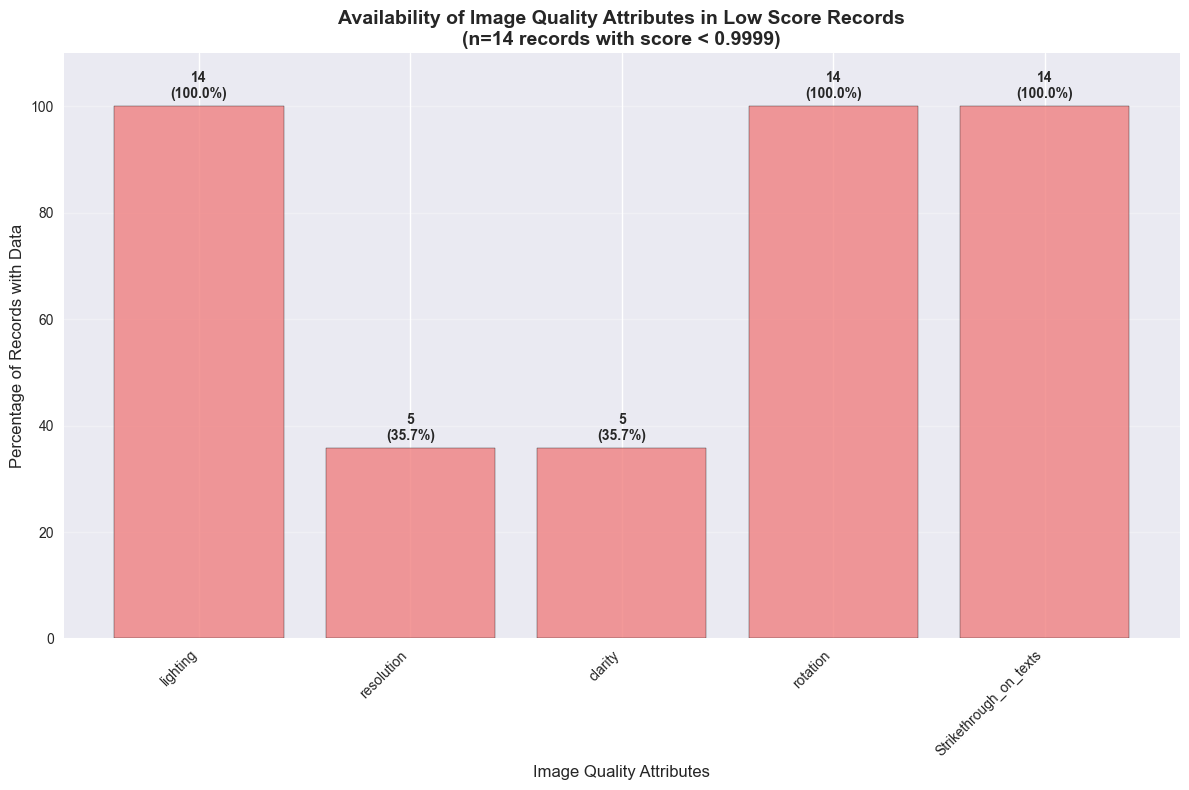

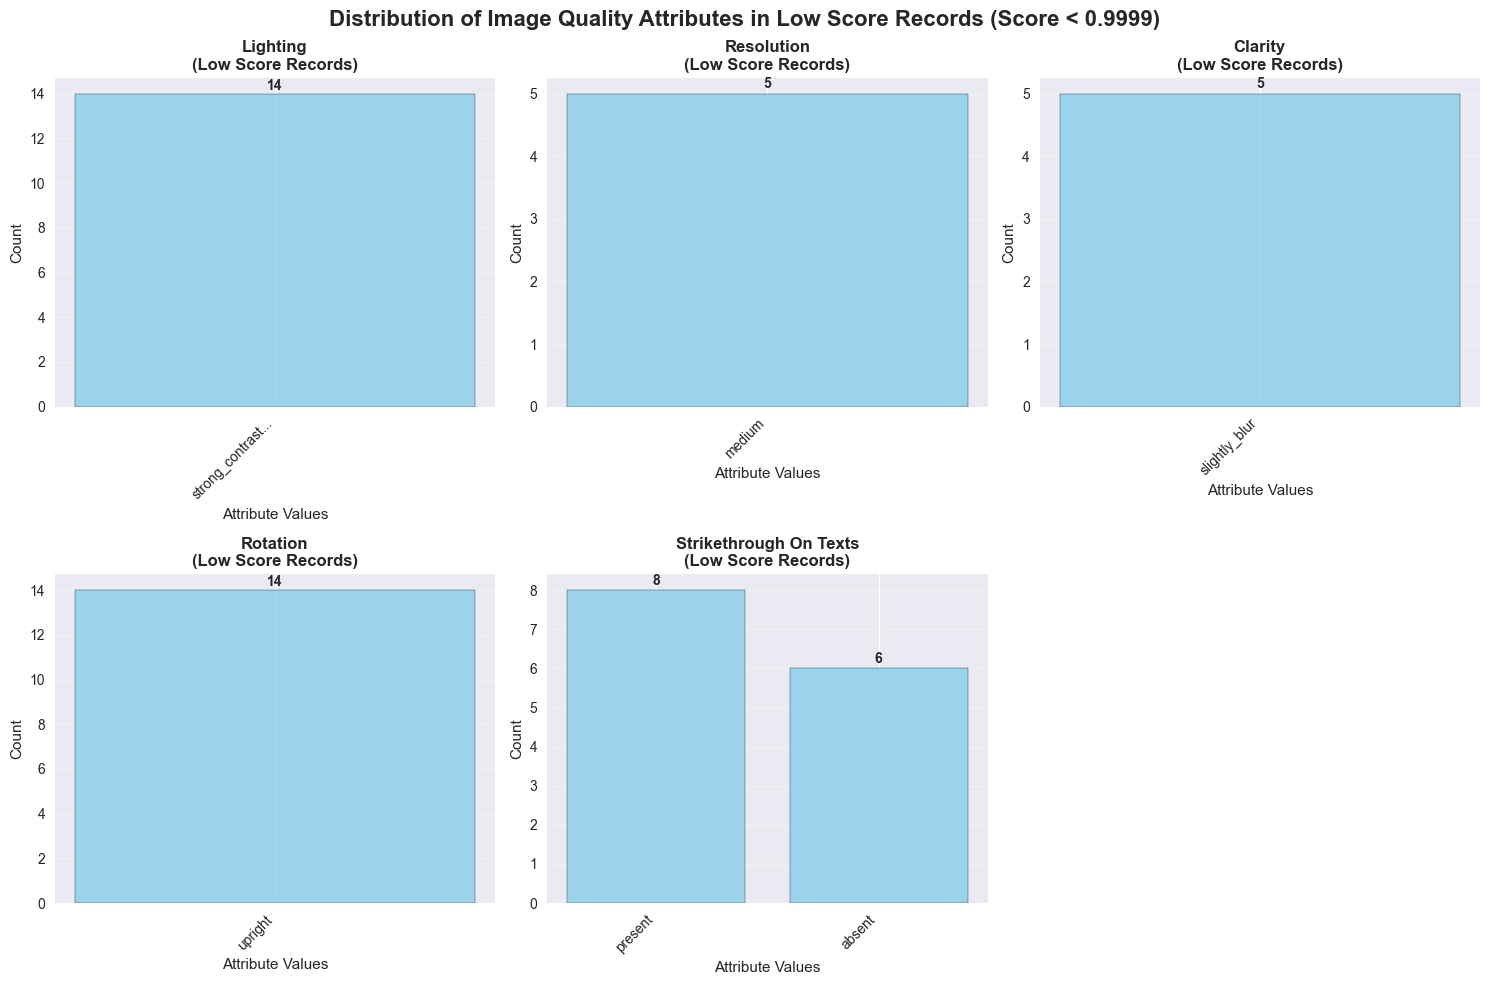

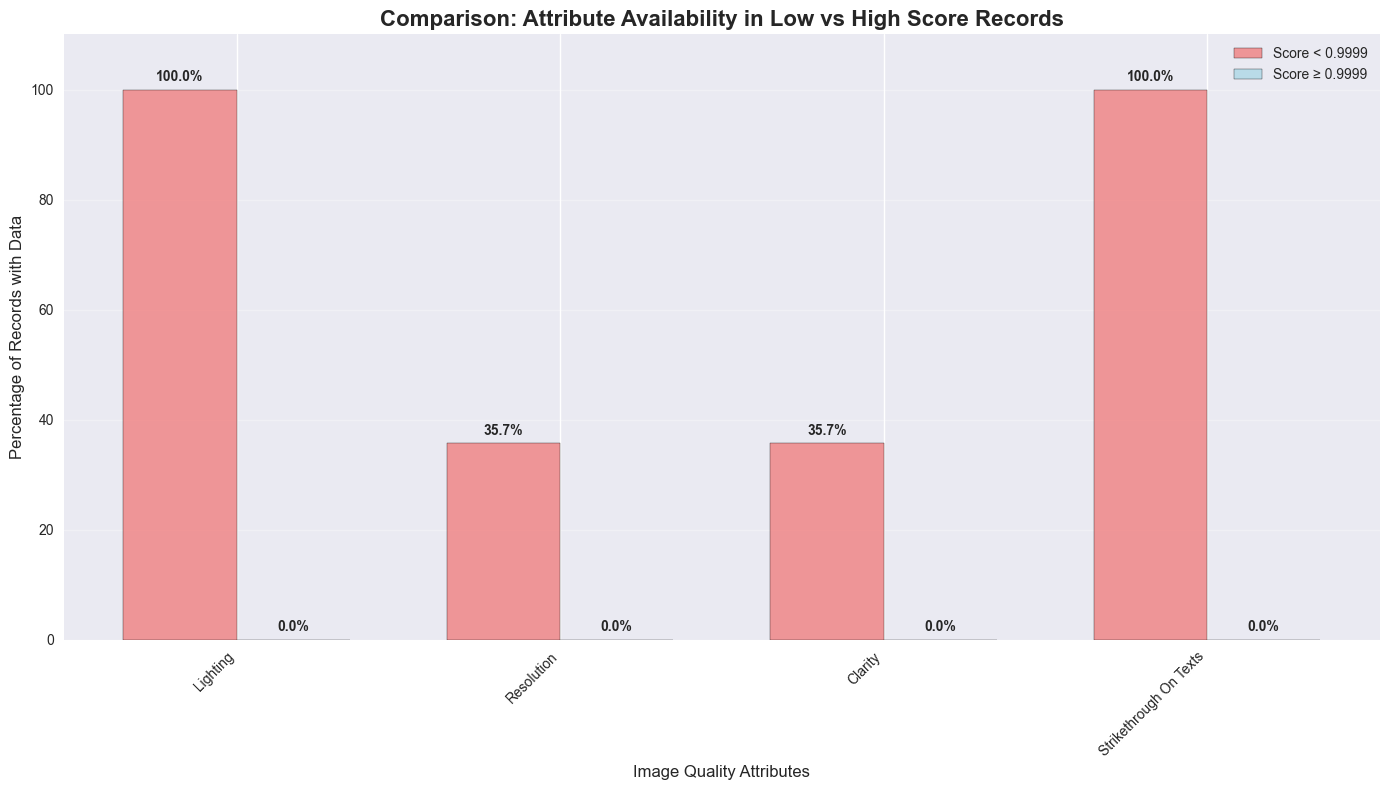

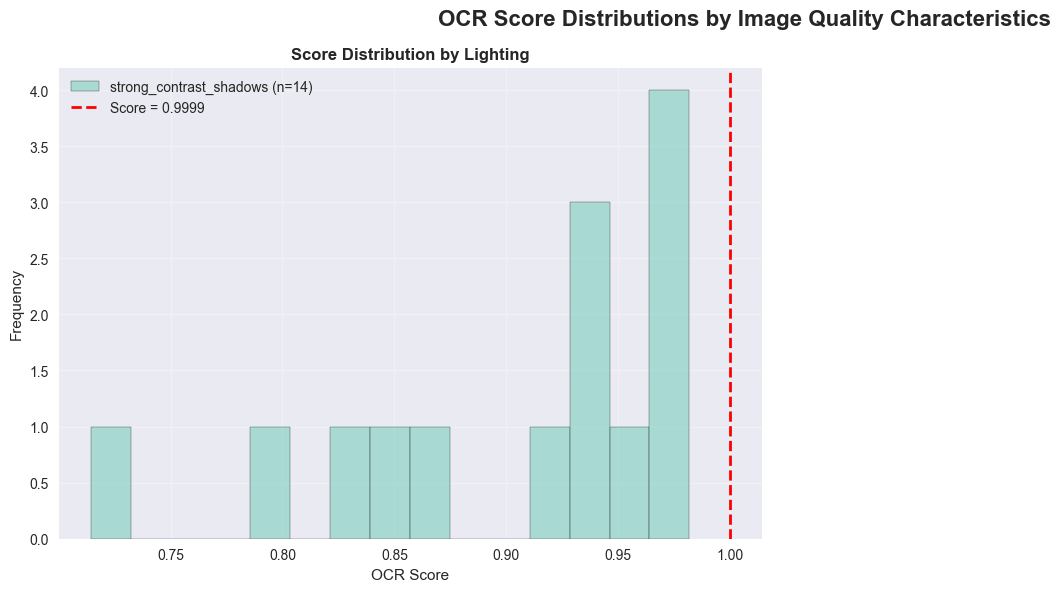


All charts displayed successfully!


In [125]:
#!/usr/bin/env python3
"""
Low Score Analysis: Analyze records with OCR scores below a user-defined threshold
Focus on image quality characteristics for poorly performing OCR
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

def load_and_parse_data(csv_path):
    """Load CSV and parse the Image_quality JSON column."""
    print("Loading data...")
    df = pd.read_csv(csv_path)
    
    # Parse the Image_quality JSON column
    image_quality_data = []
    
    for idx, row in df.iterrows():
        try:
            if pd.notna(row['Image_quality']) and row['Image_quality'].strip():
                json_str = row['Image_quality'].strip()
                if not json_str.startswith('{'):
                    continue
                    
                quality_dict = json.loads(json_str)
                quality_dict['score'] = row['score']
                quality_dict['length'] = row['length']
                quality_dict['question_number'] = row['question_number']
                quality_dict['pdf_name'] = row['pdf_name']
                image_quality_data.append(quality_dict)
        except (json.JSONDecodeError, KeyError) as e:
            continue
    
    quality_df = pd.DataFrame(image_quality_data)
    print(f"Successfully parsed {len(quality_df)} records with valid image quality data")
    
    return df, quality_df

def analyze_low_scores(quality_df, threshold):
    """Analyze records with scores below threshold."""
    
    # Filter low score records
    low_scores = quality_df[quality_df['score'] < threshold].copy()
    total_records = len(quality_df)
    low_score_count = len(low_scores)
    
    print(f"\n{'='*60}")
    print(f"LOW SCORE ANALYSIS (Score < {threshold})")
    print(f"{'='*60}")
    print(f"Total records: {total_records}")
    print(f"Records with score < {threshold}: {low_score_count}")
    print(f"Percentage of low scores: {(low_score_count/total_records)*100:.2f}%")
    print(f"{'='*60}")
    
    # Quality attributes to analyze
    quality_attributes = ['handwriting', 'writing_style', 'lighting', 'resolution', 
                         'text_alignment', 'clarity', 'rotation', 'Strikethrough_on_texts']
    
    # Count availability of each attribute in low score records
    attribute_counts = {}
    attribute_distributions = {}
    
    for attr in quality_attributes:
        if attr in low_scores.columns:
            # Count non-null values
            non_null_count = low_scores[attr].notna().sum()
            attribute_counts[attr] = non_null_count
            
            # Get distribution of values
            if non_null_count > 0:
                value_counts = low_scores[attr].value_counts()
                attribute_distributions[attr] = value_counts
                
                print(f"\n{attr.upper()}:")
                print(f"  Records with {attr} data: {non_null_count}/{low_score_count} ({(non_null_count/low_score_count)*100:.1f}%)")
                for value, count in value_counts.items():
                    if pd.notna(value):
                        print(f"  - {value}: {count} ({(count/non_null_count)*100:.1f}%)")
    
    return low_scores, attribute_counts, attribute_distributions

def create_availability_chart(attribute_counts, low_score_count, threshold):
    """Create a bar chart showing attribute availability in low score records."""
    
    plt.figure(figsize=(12, 8))
    
    # Prepare data
    attributes = list(attribute_counts.keys())
    counts = list(attribute_counts.values())
    percentages = [(count/low_score_count)*100 for count in counts]
    
    # Create bar chart
    bars = plt.bar(attributes, percentages, color='lightcoral', edgecolor='black', alpha=0.8)
    
    # Add value labels on bars
    for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
    
    plt.title(f'Availability of Image Quality Attributes in Low Score Records\n(n={low_score_count} records with score < {threshold})', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Image Quality Attributes', fontsize=12)
    plt.ylabel('Percentage of Records with Data', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 110)
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

def create_distribution_charts(low_scores, attribute_distributions, threshold):
    """Create detailed distribution charts for each attribute."""
    
    # Calculate number of subplots needed
    available_attrs = [attr for attr in attribute_distributions.keys() if len(attribute_distributions[attr]) > 0]
    n_attrs = len(available_attrs)
    
    if n_attrs == 0:
        print("No attributes with sufficient data for distribution charts")
        return
    
    # Create subplots
    cols = 3
    rows = (n_attrs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    
    if rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Flatten axes for easier indexing
    axes_flat = axes.flatten()
    
    for i, attr in enumerate(available_attrs):
        if i < len(axes_flat):
            ax = axes_flat[i]
            
            # Get data for this attribute
            data = attribute_distributions[attr]
            
            # Create bar chart
            bars = ax.bar(range(len(data)), data.values, color='skyblue', edgecolor='black', alpha=0.8)
            
            # Customize chart
            ax.set_title(f'{attr.replace("_", " ").title()}\n(Low Score Records)', fontweight='bold')
            ax.set_xlabel('Attribute Values')
            ax.set_ylabel('Count')
            ax.set_xticks(range(len(data)))
            ax.set_xticklabels([str(x)[:15] + '...' if len(str(x)) > 15 else str(x) 
                               for x in data.index], rotation=45, ha='right')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Add value labels
            for bar, value in zip(bars, data.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                       str(value), ha='center', va='bottom', fontweight='bold')
    
    # Hide unused subplots
    for i in range(n_attrs, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.suptitle(f'Distribution of Image Quality Attributes in Low Score Records (Score < {threshold})', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

def create_comparison_chart(quality_df, threshold):
    """Compare attribute distributions between low and high score records."""
    
    low_scores = quality_df[quality_df['score'] < threshold]
    high_scores = quality_df[quality_df['score'] >= threshold]
    
    quality_attributes = ['handwriting', 'writing_style', 'lighting', 'resolution', 
                         'text_alignment', 'clarity', 'Strikethrough_on_texts']
    
    # Calculate availability percentages
    low_percentages = []
    high_percentages = []
    attr_labels = []
    
    for attr in quality_attributes:
        if attr in quality_df.columns:
            low_pct = (low_scores[attr].notna().sum() / len(low_scores)) * 100 if len(low_scores) > 0 else 0
            high_pct = (high_scores[attr].notna().sum() / len(high_scores)) * 100 if len(high_scores) > 0 else 0
            
            low_percentages.append(low_pct)
            high_percentages.append(high_pct)
            attr_labels.append(attr.replace('_', ' ').title())
    
    # Create comparison chart
    x = np.arange(len(attr_labels))
    width = 0.35
    
    plt.figure(figsize=(14, 8))
    
    bars1 = plt.bar(x - width/2, low_percentages, width, label=f'Score < {threshold}', 
                    color='lightcoral', edgecolor='black', alpha=0.8)
    bars2 = plt.bar(x + width/2, high_percentages, width, label=f'Score ≥ {threshold}', 
                    color='lightblue', edgecolor='black', alpha=0.8)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.title('Comparison: Attribute Availability in Low vs High Score Records', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Image Quality Attributes', fontsize=12)
    plt.ylabel('Percentage of Records with Data', fontsize=12)
    plt.xticks(x, attr_labels, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim(0, 110)
    
    plt.tight_layout()
    plt.show()

def create_score_distribution_by_quality(quality_df, threshold):
    """Show how scores are distributed for different quality characteristics."""
    
    quality_attributes = ['clarity', 'lighting', 'resolution', 'handwriting', 'writing_style']
    
    available_attrs = [attr for attr in quality_attributes if attr in quality_df.columns 
                      and quality_df[attr].notna().sum() > 10]  # Only include if we have enough data
    
    if len(available_attrs) == 0:
        print("Not enough data for quality-based score distribution")
        return
    
    # Create subplots
    cols = 2
    rows = (len(available_attrs) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6*rows))
    
    if rows == 1 and cols == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)
    
    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, attr in enumerate(available_attrs):
        if i < len(axes_flat):
            ax = axes_flat[i]
            
            # Get unique values for this attribute
            unique_vals = quality_df[quality_df[attr].notna()][attr].unique()
            
            colors = sns.color_palette("Set3", len(unique_vals))
            
            for j, val in enumerate(unique_vals):
                if pd.notna(val):
                    subset_scores = quality_df[quality_df[attr] == val]['score']
                    ax.hist(subset_scores, bins=15, alpha=0.7, label=f'{val} (n={len(subset_scores)})',
                           color=colors[j], edgecolor='black')
            
            # Add vertical line at threshold
            ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Score = {threshold}')
            
            ax.set_title(f'Score Distribution by {attr.replace("_", " ").title()}', fontweight='bold')
            ax.set_xlabel('OCR Score')
            ax.set_ylabel('Frequency')
            ax.legend()
            ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(available_attrs), len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    plt.suptitle('OCR Score Distributions by Image Quality Characteristics', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

def run_analysis(csv_path, threshold=None):
    """Run the complete analysis with user-defined threshold."""
    
    # Get threshold from user if not provided
    if threshold is None:
        try:
            threshold = float(input("Enter the threshold for low scores (e.g., 0.5): "))
        except ValueError:
            print("Invalid input. Using default threshold of 0.5")
            threshold = 0.5
    
    print(f"Using threshold: {threshold}")
    
    # Load and parse data
    df, quality_df = load_and_parse_data(csv_path)
    
    if len(quality_df) == 0:
        print("No valid data found!")
        return
    
    # Analyze low scores
    low_scores, attribute_counts, attribute_distributions = analyze_low_scores(quality_df, threshold)
    
    if len(low_scores) == 0:
        print(f"No records found with score < {threshold}!")
        return
    
    print(f"\nGenerating charts for {len(low_scores)} low score records...")
    
    # Create visualizations
    create_availability_chart(attribute_counts, len(low_scores), threshold)
    create_distribution_charts(low_scores, attribute_distributions, threshold)
    create_comparison_chart(quality_df, threshold)
    create_score_distribution_by_quality(quality_df, threshold)
    
    print("\nAll charts displayed successfully!")
    
    return quality_df, low_scores

# For use in Jupyter notebook
def analyze_with_threshold(threshold):
    """Convenience function for Jupyter notebook use."""
    csv_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/filtered_text_1.csv"
    return run_analysis(csv_path, threshold)

if __name__ == "__main__":
    csv_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z3_ocr_gemini_pcmb_13.3/maths/cer_pdf/filtered_text_1.csv"
    run_analysis(csv_path)
